# Data Analysis

Analysis and visualization of experiment data.

Please use `warn` or `error` to log any unexpected warnings or errors when plotting/processing the data.
Please insert any code blocks before the last `check_results()` codeblock.

In [141]:
from colorama import Fore, Back, Style
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import matplotlib.axes as axes
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.container as container
import matplotlib.patches as patches
from typing import List, cast
from IPython.display import display
import os
import re
import math
from pathlib import Path
plt.rcParams['figure.dpi'] = 150

PALETTE_COLORS = sns.color_palette('pastel')
sns.set_theme(style="whitegrid", palette="pastel", font_scale=0.8)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def to_snake_case(text: str) -> str:
    """Convert text to snake_case, and removes any punctuation symbols
    that make it unsuitable to be used in a file name.

    Args:
        text (str): String to convert.

    Returns:
        str: String in snake_case.
    """
    # Replace all non-alphanumeric characters (excluding underscores) with a single space.
    text = re.sub(r'[^\w\s-]', ' ', text)

    # Convert PascalCase to snake_case
    text = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', text)
    text = text.lower()

    # Convert Space Case to snake_case
    text = re.sub(r'[\s-]+', '_', text)

    # Remove repeating or trailing underscores
    text = re.sub(r'_{2,}', '_', text)
    text = text.strip('_')
    return text

ERRORS: List[str] = []
WARNINGS: List[str] = []

def error(msg: str):
    """Prints an error.

    Args:
        msg (str): Error message.
    """
    global ERRORS
    ERRORS.append(msg)
    print(Fore.RED + Style.BRIGHT + f"🛑 Error: {msg}")

def warn(msg: str):
    """Prints a warning.

    Args:
        msg (str): Warning message.
    """
    global WARNINGS
    WARNINGS.append(msg)
    print(Fore.YELLOW + Style.BRIGHT + f"⚠️ Warn: {msg}")

def check_results():
    """Prints any errors or warnings that were encountered.
    """
    print("Data Analysis Results:")
    if len(ERRORS) > 0:
        print(Fore.RED + Style.BRIGHT + f"🛑 Errors: {len(ERRORS)}")
        for msg in ERRORS:
            print(Fore.RED + Style.BRIGHT + f"  - {msg}")
    if len(WARNINGS) > 0:
        print(Fore.YELLOW + Style.BRIGHT + f"⚠️ Warn: {len(WARNINGS)}")
        for msg in WARNINGS:
            print(Fore.YELLOW + Style.BRIGHT + f"  - {msg}")

In [142]:
# SCENE_SUMMARY_CSV_PATH = "../tests/scenes/final/scene_summary.csv"
SCENE_SUMMARY_CSV_PATH = "./data/scene_summary.csv"
EXPERIMENT_SUMMARY_CSV_PATH = "./data/IROS/real_final_experiment_summary.csv"
PLOT_PREFIX = ""
PLOTS_PATH = "./plots"
RUNS_PATH = "./runs"
ROOT_PATH = ".."
os.makedirs(PLOTS_PATH, exist_ok=True)

# Scene summary DataFrame
#
# Each row represents a single scene, and stores information about 
# that scene, such as the objects that are initially on the table, on the floor, etc. 
sc_df = pd.read_csv(SCENE_SUMMARY_CSV_PATH)
display(sc_df.info(verbose=True))
display(sc_df)

# Experiment summary DataFrame
# 
# Each row represents a single experiment, and stores information about 
# that experiment, such as the result of the experiments, any errors, etc.
ex_df = pd.read_csv(EXPERIMENT_SUMMARY_CSV_PATH)

# bg_fix_df = pd.read_csv("./data/all_bug_fixed_experiment_summary.csv")
# # Rename ex_df methods with dg_only to dg_only_new
# ex_df['Method'] = ex_df['Method'].apply(lambda x: x.replace('dg_only', 'dg_only_new'))

# # Stack bg_fix_df into ex_df
# ex_df = pd.concat([ex_df, bg_fix_df], ignore_index=True)

display(ex_df.info(verbose=True))
display(ex_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Scene          45 non-null     object
 1   Path           45 non-null     object
 2   All Objects    45 non-null     object
 3   Floor Objects  22 non-null     object
 4   Table Objects  45 non-null     object
dtypes: object(5)
memory usage: 1.9+ KB


None

,Scene,Path,All Objects,Floor Objects,Table Objects
0,unstructured_10,tests/scenes/final/unstructured_10.xml,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000065_0,obj_000043_0,obj_000068_0,obj_000052_0,obj_000045_0,obj_000063_0",NaN,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000065_0,obj_000043_0,obj_000068_0,obj_000052_0,obj_000045_0,obj_000063_0"
1,unstructured_134,tests/scenes/final/unstructured_134.xml,"obj_000054_0,obj_000062_0,obj_000066_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000065_0,obj_000060_0,obj_000048_0,obj_000044_0,obj_000041_0,obj_000068_0,obj_000059_0,obj_000052_0,obj_000042_0,obj_000057_0,obj_000056_0,obj_000064_0,obj_000063_0",obj_000062_0,"obj_000054_0,obj_000066_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000065_0,obj_000060_0,obj_000048_0,obj_000044_0,obj_000041_0,obj_000068_0,obj_000059_0,obj_000052_0,obj_000042_0,obj_000057_0,obj_000056_0,obj_000064_0,obj_000063_0"
2,difficult_130,tests/scenes/final/difficult_130.xml,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000048_1,obj_000044_0,obj_000049_0,obj_000045_0,obj_000042_0,obj_000042_1,obj_000064_0",NaN,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000048_1,obj_000044_0,obj_000049_0,obj_000045_0,obj_000042_0,obj_000042_1,obj_000064_0"
3,unstructured_36,tests/scenes/final/unstructured_36.xml,"obj_000003_0,obj_000012_0,obj_000013_0,obj_000054_0,obj_000047_0,obj_000059_0,obj_000059_1,obj_000050_0,obj_000050_1,obj_000069_0,obj_000073_0,obj_000079_0,obj_000079_1",obj_000013_0,"obj_000003_0,obj_000012_0,obj_000054_0,obj_000047_0,obj_000059_0,obj_000059_1,obj_000050_0,obj_000050_1,obj_000069_0,obj_000073_0,obj_000079_0,obj_000079_1"
4,difficult_149,tests/scenes/final/difficult_149.xml,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000062_1,obj_000055_0,obj_000048_0,obj_000043_0,obj_000043_1,obj_000061_0,obj_000058_0,obj_000041_0,obj_000059_0,obj_000056_0,obj_000063_0",NaN,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000062_1,obj_000055_0,obj_000048_0,obj_000043_0,obj_000043_1,obj_000061_0,obj_000058_0,obj_000041_0,obj_000059_0,obj_000056_0,obj_000063_0"
...,...,...,...,...,...
40,structured_590,tests/scenes/final/structured_590.xml,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000059_0,obj_000052_0,obj_000049_0,obj_000056_0,obj_000056_1,obj_000021_0,obj_000029_0,obj_000116_0,obj_000122_0,obj_000128_0,obj_000128_1,obj_000135_0,obj_000085_0",obj_000029_0,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000059_0,obj_000052_0,obj_000049_0,obj_000056_0,obj_000056_1,obj_000021_0,obj_000116_0,obj_000122_0,obj_000128_0,obj_000128_1,obj_000135_0,obj_000085_0"
41,unstructured_105,tests/scenes/final/unstructured_105.xml,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000071_0,obj_000071_1,obj_000072_0,obj_000074_0,obj_000077_0,obj_000077_1,obj_000078_0,obj_000078_1,obj_000078_2,obj_000079_0",NaN,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000071_0,obj_000071_1,obj_000072_0,obj_000074_0,obj_000077_0,obj_000077_1,obj_000078_0,obj_000078_1,obj_000078_2,obj_000079_0"
42,difficult_179,tests/scenes/final/difficult_179.xml,"obj_000015_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000048_0,obj_000044_0,obj_000044_1,obj_000064_0,obj_000029_0,obj_000032_0,obj_000069_0,obj_000072_0,obj_000072_1,obj_000072_2,obj_000073_0,obj_000074_0,obj_000077_0","obj_000032_0,obj_000073_0","obj_000015_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000048_0,obj_000044_0,obj_000044_1,obj_000064_0,obj_000029_0,obj_000069_0,obj_000072_0,obj_000072_1,obj_000072_2,obj_000074_0,obj_000077_0"
43,structured_586,tests/scenes/final/structured_586.xml,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000007_0,obj_000017_0,obj_000054_0,obj_000055_0,obj_000043_0,obj_000045_0,obj_000064_0,obj_000063_0,obj_000026_0,obj_000081_0,obj_000083_0,obj_000084_0,obj_000089_0",NaN,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000007_0,obj_000017_0,obj_000054_0,obj_000055_0,obj_000043_0,obj_000045_0,obj_000064_0,obj_000063_0,obj_000026_0,obj_000081_0,obj_000083_0,obj_000084_0,obj_000089_0"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Init Import Duration                           45 non-null     object 
 1   Init Perception Planning Duration              45 non-null     object 
 2   Init Functions Duration                        45 non-null     object 
 3   Init Post Duration                             45 non-null     object 
 4   Total Init Duration                            45 non-null     object 
 5   Target Object                                  45 non-null     object 
 6   Pick Count                                     45 non-null     float64
 7   Grasp Choice (Seg ID)                          45 non-null     object 
 8   Grasp Choice Duration                          45 non-null     object 
 9   Grasp Score                                    45 non-nu

None

,Init Import Duration,Init Perception Planning Duration,Init Functions Duration,Init Post Duration,Total Init Duration,Target Object,Pick Count,Grasp Choice (Seg ID),Grasp Choice Duration,Grasp Score,Total Computation Duration,Total Grasp Planning Duration,Total Motion Planning Duration,Object Name,Grasp Success,Grasped,Total Execution Duration,Retract Success,Dropped,Grasp Result,Retrieved Target Object,Grasp Retracted Objects,Accidental Dropped Objects,Grasp Result finished Count,Grasp Result timeout Count,Grasp Result no_valid_grasps_found Count,Grasp Result grasp_choice_failed Count,Grasp Result no_valid_motion_plan_found Count,Grasp Success True Count,Grasp Success False Count,Grasp Retracted Objects Count,Accidental Dropped Objects Count,Scene,Experiment Path,Method,Total Experiment Time,Error
0,5.663674116134644,26.55966019630432,2.6226043701171875e-05,3.576278686523437e-06,32.22351908683777,yellow mustard bottle.,4.0,"2.0,1.0,3.0,0.0","0.9170467853546144,0.7652027606964111,0.6480424404144287,0.3990662097930908","0.6133018732070923,0.58592289686203,0.5351384282112122,0.4151737093925476","55.486337423324585,37.79410982131958,35.787490129470825,30.61031222343445","24.941341876983643,23.043010473251343,21.294193029403687,16.948882579803467","4.396048545837402,4.111063718795776,3.5473058223724365,2.6881537437438965","white bleach bottle,window cleaner,black box,yellow mustard bottle","True,True,True,True","['white bleach bottle'],['window cleaner'],['black box', 'jello box'],['yellow mustard bottle']","40.945151805877686,38.92606329917908,44.75257587432861,37.726728677749634","True,True,True,True",orange,"finished,finished,finished,finished",True,"white bleach bottle,black box,yellow mustard bottle,window cleaner,jello box",orange,4,0,0,0,0,4,0,5,1,2,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only,dg_only,572.329544,NaN
1,5.693267345428467,26.79215836524964,3.075599670410156e-05,3.337860107421875e-06,32.4856493473053,yellow mustard bottle.,2.0,"5.0,0.0","1.3828938007354736,0.8413152694702148","0.5297104716300964,0.593052864074707","43.11306691169739,29.32338094711304","22.739805936813354,17.66447615623474","10.525055646896362,3.3663463592529297","black box,yellow mustard bottle","False,True","['black box', 'jello box'],['yellow mustard bottle']","62.255866050720215,36.94136142730713","True,True",NaN,"finished,finished",True,"jello box,black box,yellow mustard bottle",NaN,2,0,0,0,0,1,1,3,0,2,trial_2025-12-06_14-29-26__scene2__dg_only/2__exp_3__yellow_mustard_bottle___dg_only,dg_only,311.099241,NaN
2,5.767622947692871,27.109098196029663,3.075599670410156e-05,3.0994415283203125e-06,32.87692761421204,yellow mustard bottle.,4.0,"1.0,1.0,3.0,0.0","1.0160362720489502,0.7427704334259033,0.6323802471160889,0.5962796211242676","0.4109383523464203,0.540682315826416,0.6439645290374756,0.406932532787323","86.34953141212463,92.08017563819884,38.45016956329346,32.80669403076172","23.458643913269043,21.619886875152588,22.49101710319519,20.706435918807983","52.251574754714966,61.625147581100464,7.767367124557495,2.1732983589172363","white bleach bottle,window cleaner,black box,yellow mustard bottle","True,True,False,True","['white bleach bottle'],['window cleaner'],['black box', 'jello box'],['yellow mustard bottle']","36.220441818237305,38.40280723571777,52.34078407287598,46.25442433357239","True,True,True,True",NaN,"finished,finished,finished,finished",True,"white bleach bottle,black box,yellow mustard bottle,window cleaner,jello box",NaN,4,0,0,0,0,3,1,5,0,2,trial_2025-12-06_14-29-26__scene2__dg_only/2__exp_2__yellow_mustard_bottle___dg_only,dg_only,710.941090,"MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_COLLISION,MotionGenStatus.INVALID_START_STATE_WORLD_

In [143]:
def post_process_ex_df(ex_df: pd.DataFrame) -> pd.DataFrame:
    """Processes a raw experiment DataFrame, adding more columns and removing invalid data.

    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to process.
    """
    # Force "Scene" to be a string column
    ex_df["Scene"] = ex_df["Scene"].astype(str)
    def process_scene_type(row):
        parts = row["Scene"].split('_')
        if len(parts) >= 2:
            return parts[-2]
        else:
            return "unknown"
    ex_df["Scene Type"] = ex_df.apply(process_scene_type, axis=1)
    ex_df["Scene"] = ex_df["Scene"].str.replace("tabletop_", "")
    ex_df["Error Count"] = ex_df["Error"].str.split(',').str.len().fillna(0).astype(int)
    ex_df["Grasp Result Count"] = ex_df["Grasp Result"].str.split(",").str.len().fillna(0).astype(int)
    ex_df["Grasp Result Failure"] = (
        ex_df["Grasp Result"]
        .str.split(",")
        .apply(lambda x: [item for item in x if item != "finished"])
        .str.join(",")
        .replace("", pd.NA) 
    )
    ex_df["Grasp Result Failure Count"] = ex_df["Grasp Result Failure"].str.split(",").str.len().fillna(0).astype(int)
    ex_df["Experiment"] = ex_df["Scene"] + " " + ex_df["Target Object"]

    # Create "Experiment Result" column based on outcomes
    conditions = []
    choices = []
    if "Dropped Target Object" in ex_df:
        conditions.append(ex_df["Dropped Target Object"] == True)
        choices.append("dropped")
    if "Retrieved Target Object" in ex_df:
        conditions.append(ex_df["Retrieved Target Object"] == True)
        choices.append("retrieved")
    if "Unhandled Error" in ex_df:
        conditions.append(ex_df["Unhandled Error"].notna())
        choices.append("error")
    if "Retrieved Target Object" in ex_df:
        conditions.append(ex_df["Retrieved Target Object"] == False)
        choices.append("timeout")

    ex_df['Experiment Result'] = np.select(conditions, choices, default='unfinished')
    ex_df["Retrieve Success"] = ex_df['Experiment Result'] == "retrieved"

    # Fix accidental dropped objects
    # Exclude target object from being considered as accidental dropped if it made the experiment fail.
    def exclude_floor_objects_and_target(ex_df: pd.DataFrame, sc_df: pd.DataFrame):
        ex_df["Accidental Dropped Objects List"] = ex_df["Accidental Dropped Objects"].fillna('').str.split(',')
        ex_df["Accidental Dropped Objects List"] = ex_df["Accidental Dropped Objects List"].apply(
            lambda x: [] if (len(x) == 1 and x[0].strip() == '') else x
        )
        display(sc_df)
        def apply_floor(row: pd.Series):
            first = row.iloc[0]
            if not isinstance(first, str):
                return set()
            return set(first.split(","))
        scene_invalid_objects = sc_df.groupby('Scene')['Floor Objects'].apply(apply_floor).to_dict()
        def filter_objects_by_scene(row):
            scene = row['Scene']
            dropped_objects = row['Accidental Dropped Objects List'] 
            invalid_set = scene_invalid_objects.get(scene, set())
            invalid_set.add(row['Target Object'])
            cleaned_list = [
                obj.strip()
                for obj in dropped_objects
                if obj.strip() and obj.strip() not in invalid_set
            ]
            return cleaned_list
        
        ex_df["Accidental Dropped Objects List"] = ex_df.apply(
            filter_objects_by_scene,
            axis=1
        )
        ex_df["Accidental Dropped Objects"] = ex_df["Accidental Dropped Objects List"].apply(
            lambda x: ", ".join(x)
        )
        ex_df["Accidental Dropped Objects Count"] = ex_df["Accidental Dropped Objects List"].apply(len)
    
    exclude_floor_objects_and_target(ex_df, sc_df)

    if "Experiment Path" not in ex_df.columns:
        ex_df["Experiment Path"] = ex_df["Scene"]

post_process_ex_df(ex_df)

display(ex_df.info(verbose=True))
display(ex_df.loc[~ex_df["Retrieve Success"] & ex_df["Accidental Dropped Objects"], ["Experiment Path", "Accidental Dropped Objects", "Target Object", "Retrieve Success"]])

,Scene,Path,All Objects,Floor Objects,Table Objects
0,unstructured_10,tests/scenes/final/unstructured_10.xml,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000065_0,obj_000043_0,obj_000068_0,obj_000052_0,obj_000045_0,obj_000063_0",NaN,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000065_0,obj_000043_0,obj_000068_0,obj_000052_0,obj_000045_0,obj_000063_0"
1,unstructured_134,tests/scenes/final/unstructured_134.xml,"obj_000054_0,obj_000062_0,obj_000066_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000065_0,obj_000060_0,obj_000048_0,obj_000044_0,obj_000041_0,obj_000068_0,obj_000059_0,obj_000052_0,obj_000042_0,obj_000057_0,obj_000056_0,obj_000064_0,obj_000063_0",obj_000062_0,"obj_000054_0,obj_000066_0,obj_000047_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000065_0,obj_000060_0,obj_000048_0,obj_000044_0,obj_000041_0,obj_000068_0,obj_000059_0,obj_000052_0,obj_000042_0,obj_000057_0,obj_000056_0,obj_000064_0,obj_000063_0"
2,difficult_130,tests/scenes/final/difficult_130.xml,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000048_1,obj_000044_0,obj_000049_0,obj_000045_0,obj_000042_0,obj_000042_1,obj_000064_0",NaN,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000048_1,obj_000044_0,obj_000049_0,obj_000045_0,obj_000042_0,obj_000042_1,obj_000064_0"
3,unstructured_36,tests/scenes/final/unstructured_36.xml,"obj_000003_0,obj_000012_0,obj_000013_0,obj_000054_0,obj_000047_0,obj_000059_0,obj_000059_1,obj_000050_0,obj_000050_1,obj_000069_0,obj_000073_0,obj_000079_0,obj_000079_1",obj_000013_0,"obj_000003_0,obj_000012_0,obj_000054_0,obj_000047_0,obj_000059_0,obj_000059_1,obj_000050_0,obj_000050_1,obj_000069_0,obj_000073_0,obj_000079_0,obj_000079_1"
4,difficult_149,tests/scenes/final/difficult_149.xml,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000062_1,obj_000055_0,obj_000048_0,obj_000043_0,obj_000043_1,obj_000061_0,obj_000058_0,obj_000041_0,obj_000059_0,obj_000056_0,obj_000063_0",NaN,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000062_1,obj_000055_0,obj_000048_0,obj_000043_0,obj_000043_1,obj_000061_0,obj_000058_0,obj_000041_0,obj_000059_0,obj_000056_0,obj_000063_0"
...,...,...,...,...,...
40,structured_590,tests/scenes/final/structured_590.xml,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000059_0,obj_000052_0,obj_000049_0,obj_000056_0,obj_000056_1,obj_000021_0,obj_000029_0,obj_000116_0,obj_000122_0,obj_000128_0,obj_000128_1,obj_000135_0,obj_000085_0",obj_000029_0,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000059_0,obj_000052_0,obj_000049_0,obj_000056_0,obj_000056_1,obj_000021_0,obj_000116_0,obj_000122_0,obj_000128_0,obj_000128_1,obj_000135_0,obj_000085_0"
41,unstructured_105,tests/scenes/final/unstructured_105.xml,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000071_0,obj_000071_1,obj_000072_0,obj_000074_0,obj_000077_0,obj_000077_1,obj_000078_0,obj_000078_1,obj_000078_2,obj_000079_0",NaN,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000071_0,obj_000071_1,obj_000072_0,obj_000074_0,obj_000077_0,obj_000077_1,obj_000078_0,obj_000078_1,obj_000078_2,obj_000079_0"
42,difficult_179,tests/scenes/final/difficult_179.xml,"obj_000015_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000048_0,obj_000044_0,obj_000044_1,obj_000064_0,obj_000029_0,obj_000032_0,obj_000069_0,obj_000072_0,obj_000072_1,obj_000072_2,obj_000073_0,obj_000074_0,obj_000077_0","obj_000032_0,obj_000073_0","obj_000015_0,obj_000053_0,obj_000055_0,obj_000067_0,obj_000048_0,obj_000044_0,obj_000044_1,obj_000064_0,obj_000029_0,obj_000069_0,obj_000072_0,obj_000072_1,obj_000072_2,obj_000074_0,obj_000077_0"
43,structured_586,tests/scenes/final/structured_586.xml,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000007_0,obj_000017_0,obj_000054_0,obj_000055_0,obj_000043_0,obj_000045_0,obj_000064_0,obj_000063_0,obj_000026_0,obj_000081_0,obj_000083_0,obj_000084_0,obj_000089_0",NaN,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000007_0,obj_000017_0,obj_000054_0,obj_000055_0,obj_000043_0,obj_000045_0,obj_000064_0,obj_000063_0,obj_000026_0,obj_000081_0,obj_000083_0,obj_000084_0,obj_000089_0"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 46 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Init Import Duration                           45 non-null     object 
 1   Init Perception Planning Duration              45 non-null     object 
 2   Init Functions Duration                        45 non-null     object 
 3   Init Post Duration                             45 non-null     object 
 4   Total Init Duration                            45 non-null     object 
 5   Target Object                                  45 non-null     object 
 6   Pick Count                                     45 non-null     float64
 7   Grasp Choice (Seg ID)                          45 non-null     object 
 8   Grasp Choice Duration                          45 non-null     object 
 9   Grasp Score                                    45 non-nu

None

,Experiment Path,Accidental Dropped Objects,Target Object,Retrieve Success


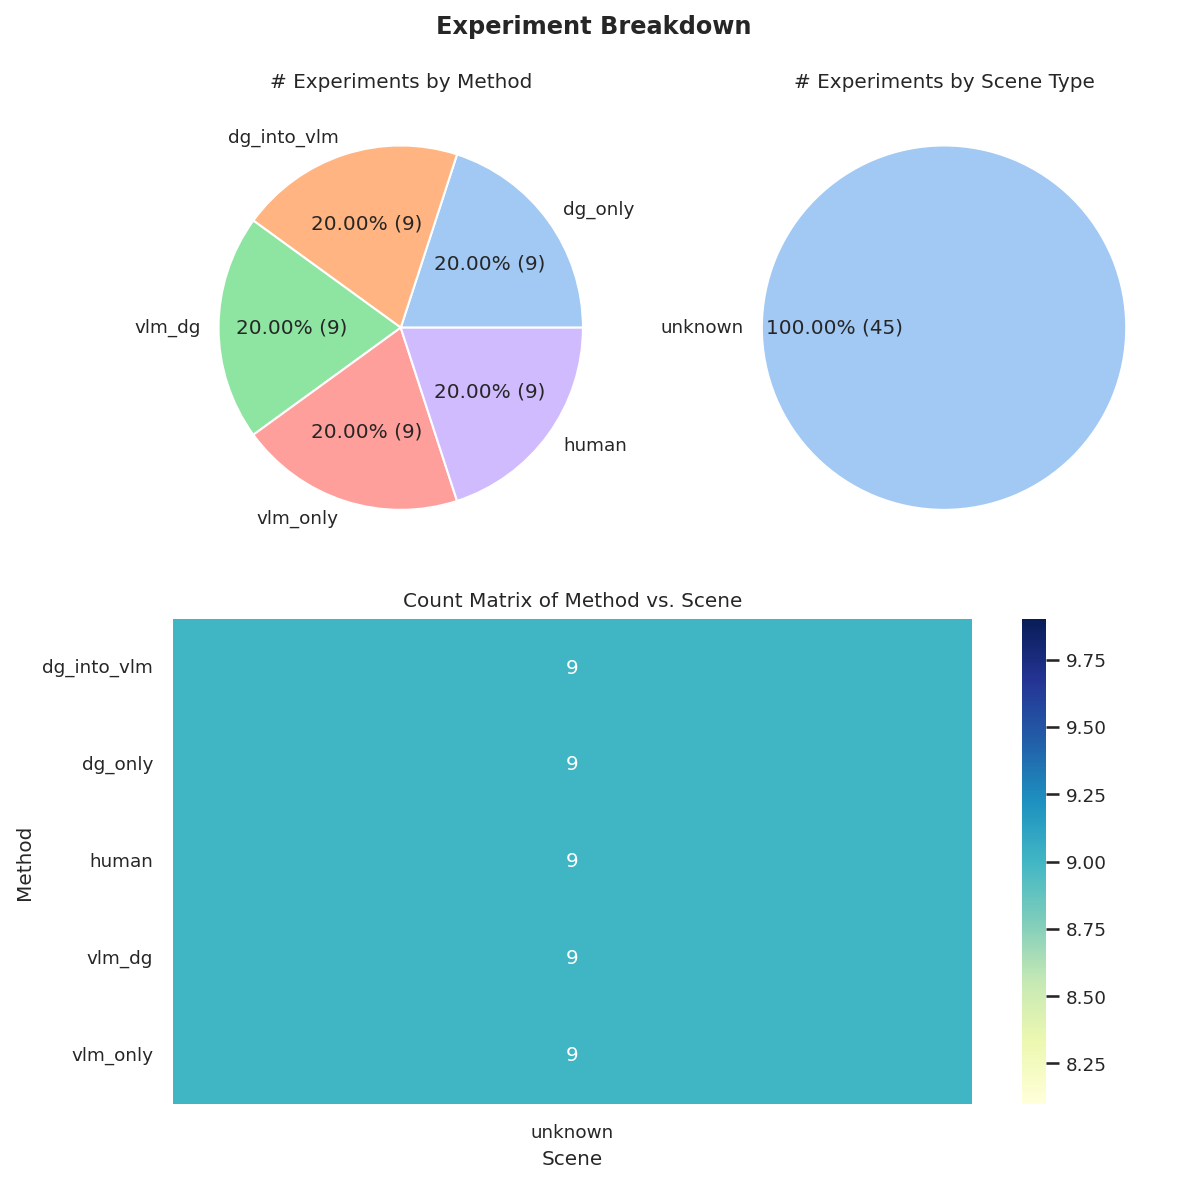

In [144]:
def plot_experiment_breakdown_df(df: pd.DataFrame):
    """Plots a breakdown of all of the experiments from an experiment DataFrame, which includes:
        - Number of Experiments by Method
        - Number of Experiments by Scene Type
        - Count Matrix of Experiments by Method and Scene Type

    Args:
        df (pd.DataFrame): Experiment DataFrame
    """
    def absolute_value(l: list, val: float):
        a  = np.round(val/100.* l.sum(), 0)
        return f"{val:.2f}% ({int(a)})"
    
    fig = plt.figure(figsize=(8, 8))
    
    # Add the two pie chart subplots to the top row
    ax1 = fig.add_subplot(2, 2, 1)  # Top-left subplot
    ax2 = fig.add_subplot(2, 2, 2)  # Top-right subplot
    
    # Add the heatmap subplot to the bottom row, spanning both columns
    ax3 = fig.add_subplot(2, 1, 2)  # Bottom subplot
    
    fig.suptitle("Experiment Breakdown", fontweight='bold')
    
    value_counts = df["Method"].value_counts()
    ax1.set_title("# Experiments by Method")
    ax1.pie(value_counts.values, labels=value_counts.index, colors=PALETTE_COLORS, autopct=lambda x: absolute_value(value_counts, x))
    
    value_counts = df["Scene Type"].value_counts()
    ax2.set_title("# Experiments by Scene Type")
    ax2.pie(value_counts.values, labels=value_counts.index, colors=PALETTE_COLORS, autopct=lambda x: absolute_value(value_counts, x))
    
    count_matrix = pd.crosstab(df['Method'], df['Scene Type'])
    sns.heatmap(count_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=ax3)
    ax3.set_title('Count Matrix of Method vs. Scene')
    ax3.set_ylabel('Method')
    ax3.set_xlabel('Scene')

    plt.tight_layout()
    plt.plot()
    plt.savefig(f"{PLOTS_PATH}/experiment_breakdown.png")

plot_experiment_breakdown_df(ex_df)

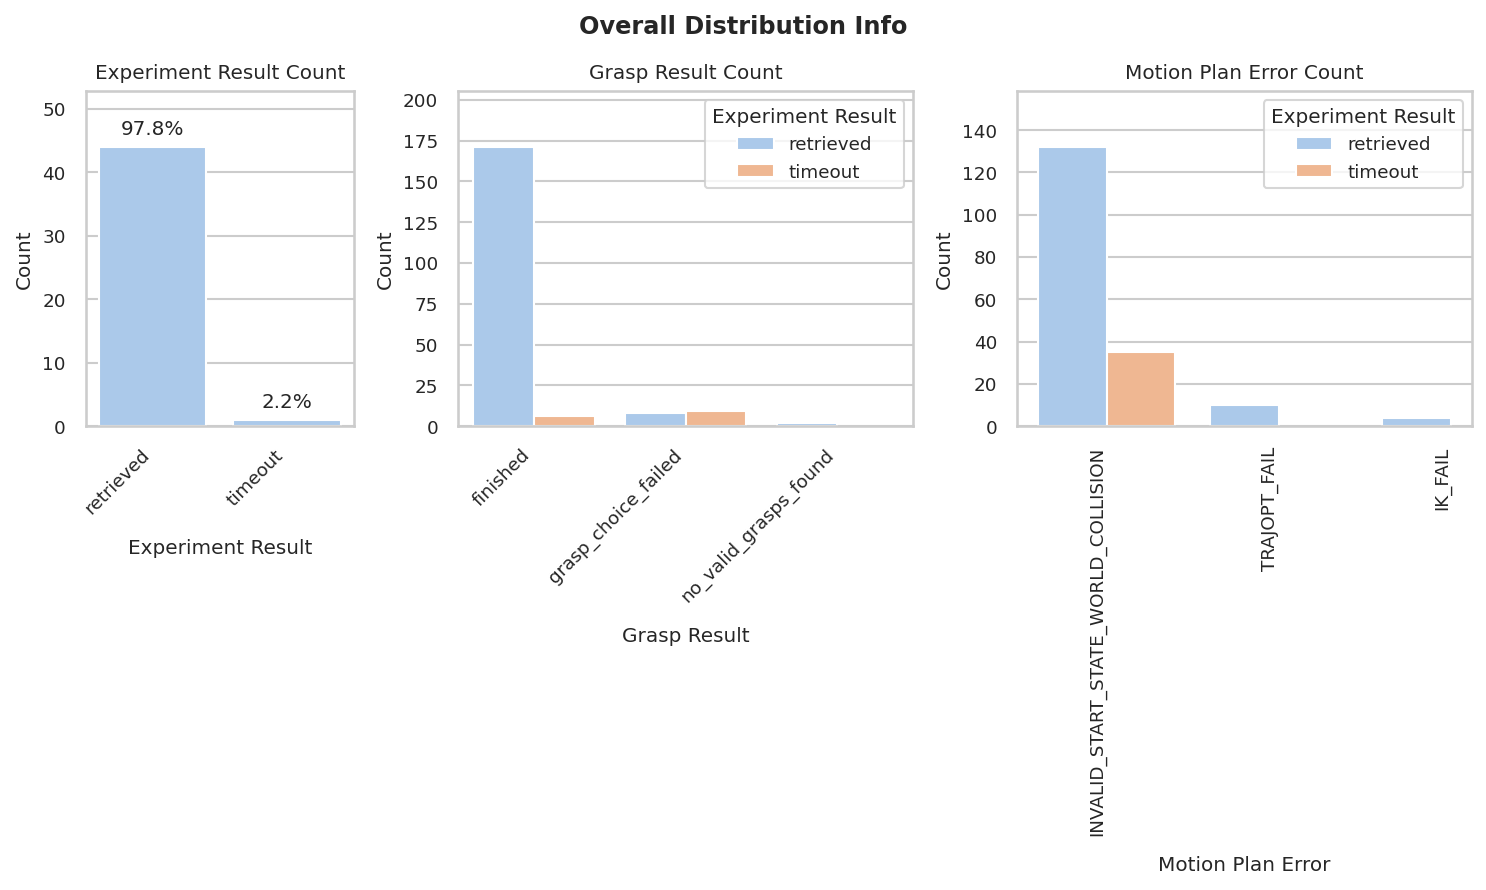

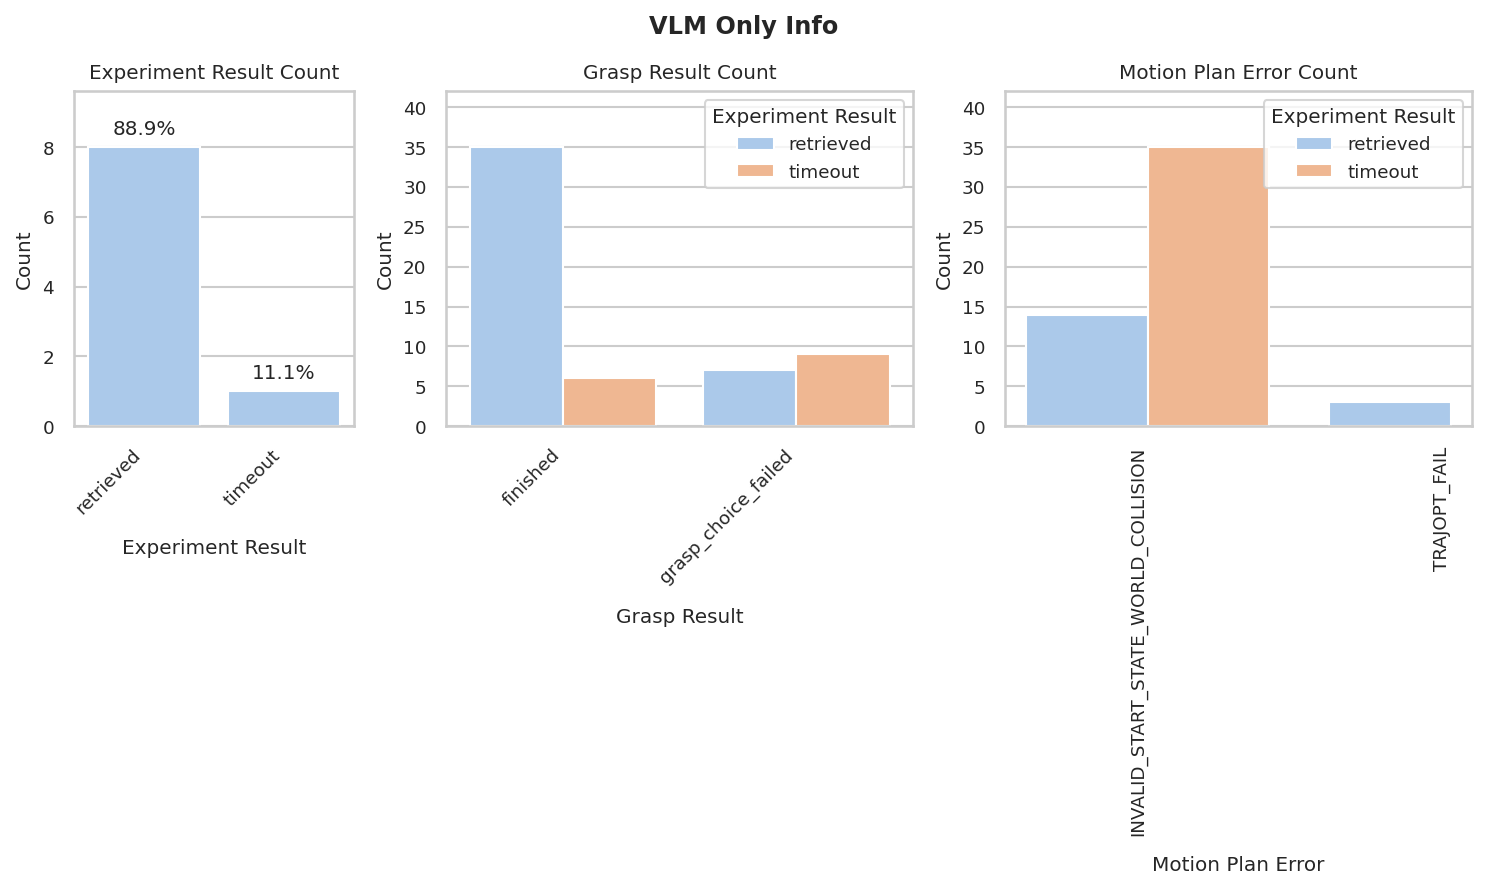

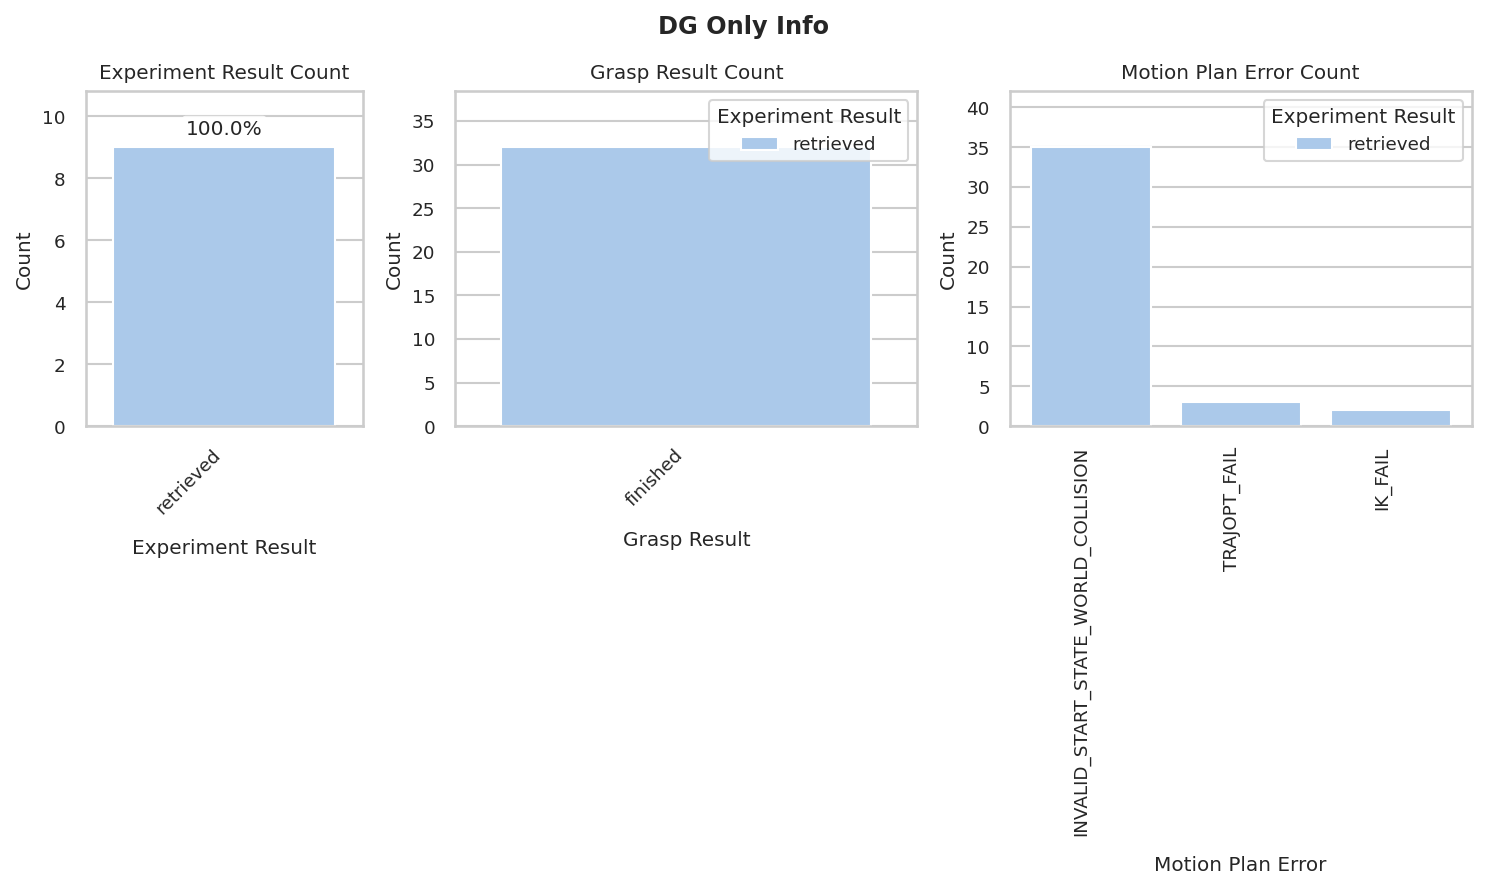

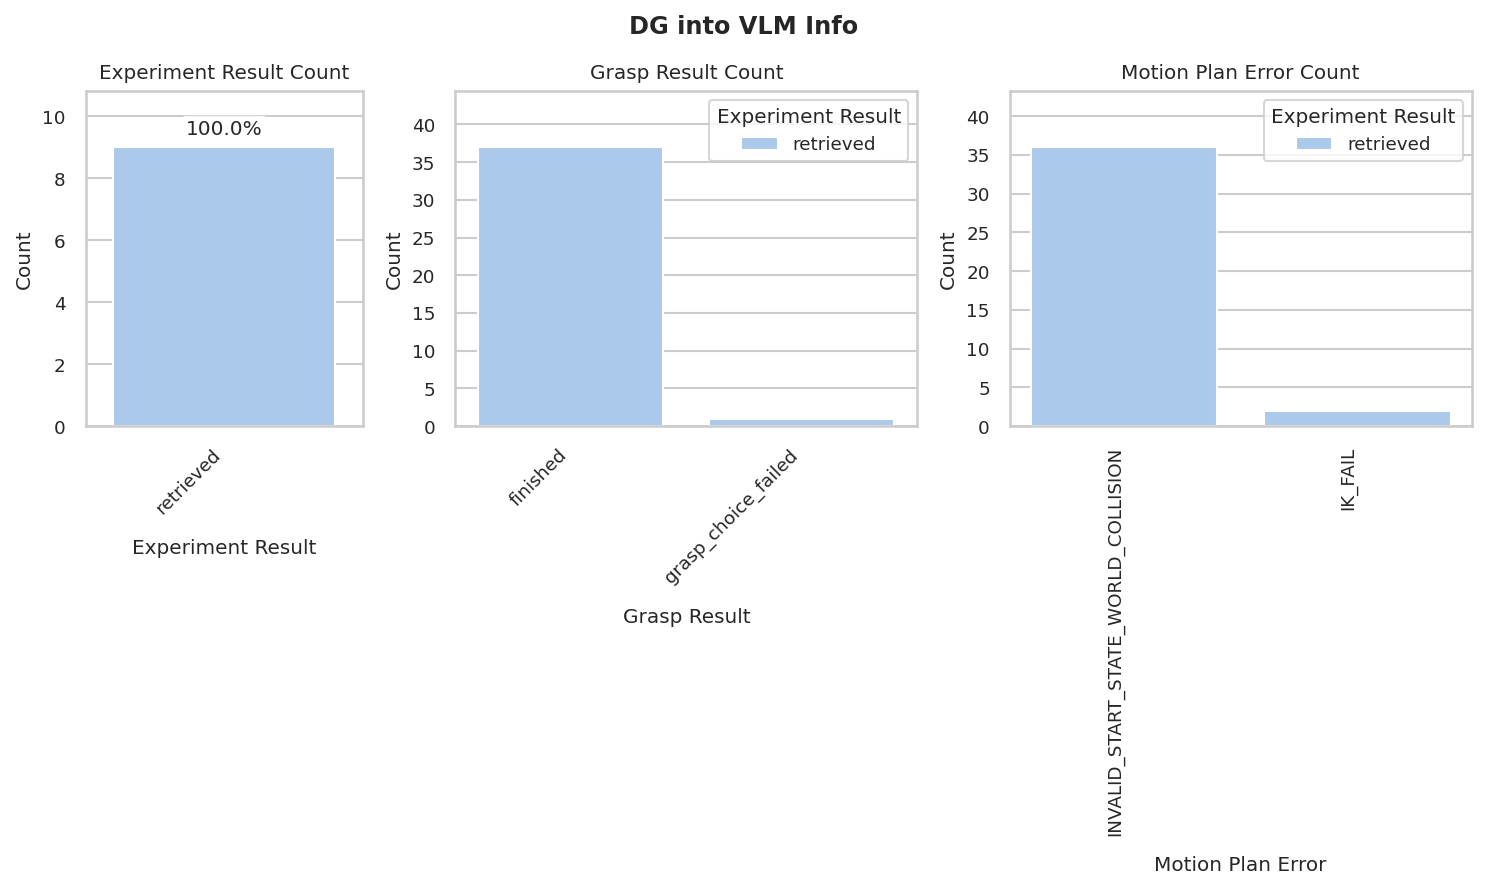

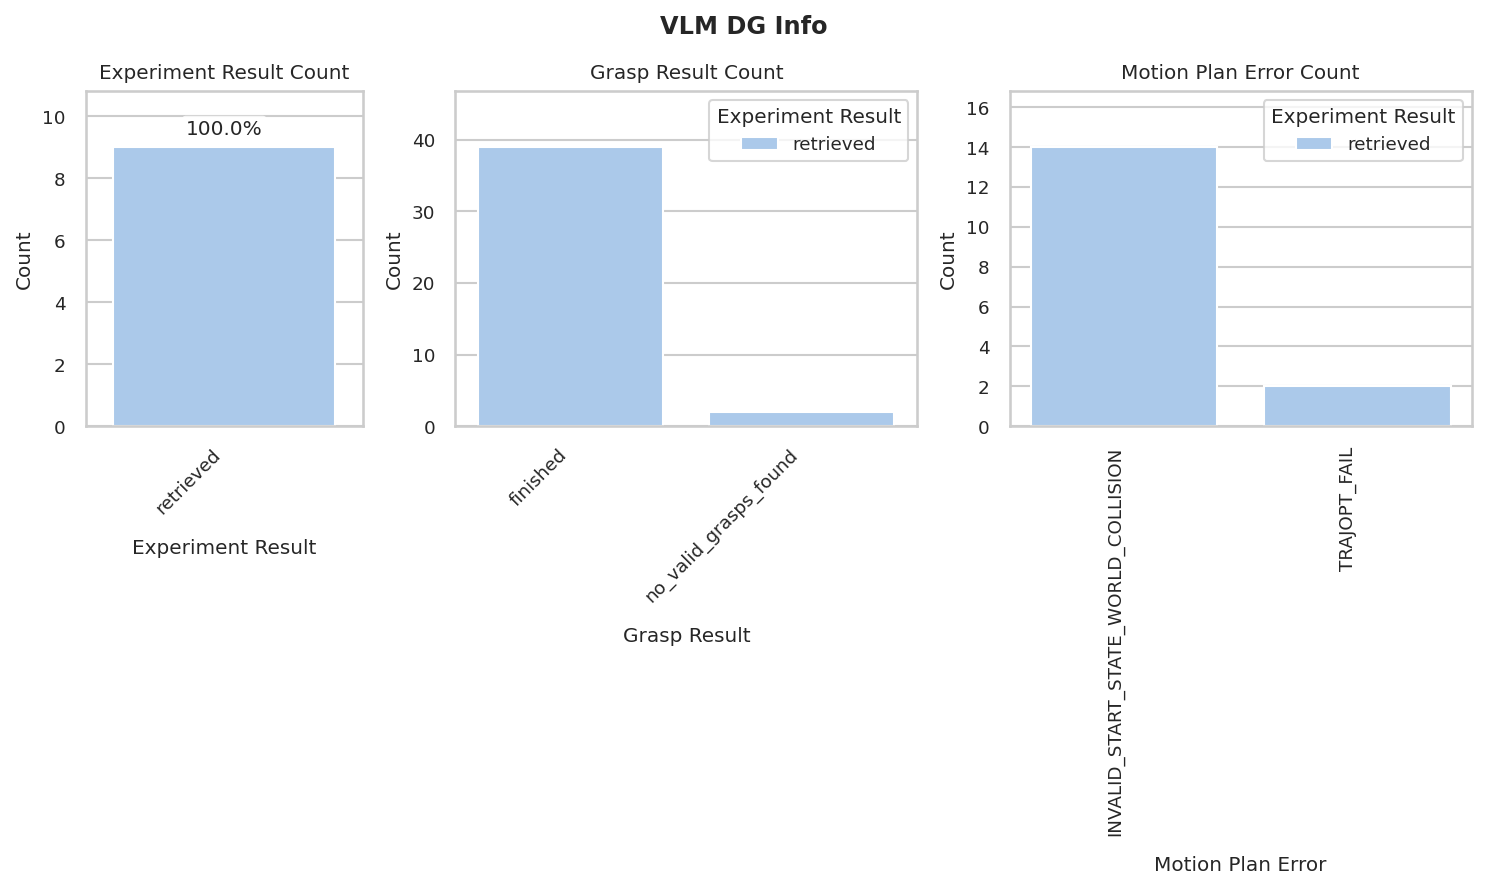

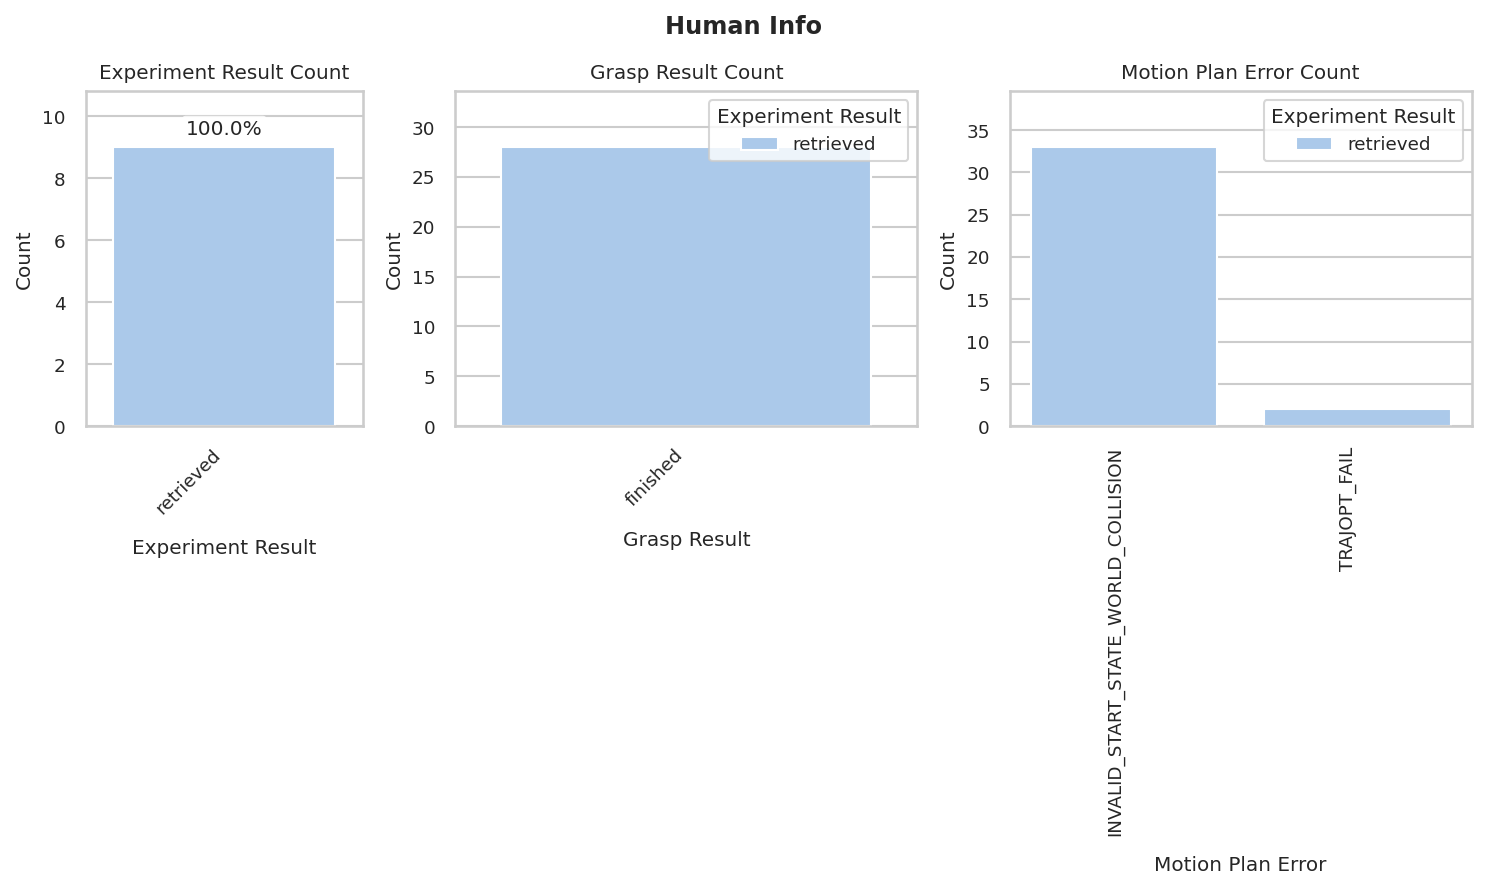

In [145]:
def plot_dist_info_df(df: pd.DataFrame, title: str = "Title"):
    """Plots an experiment DataFrame's distribution information. This includes:
        - Experiment Results (`retreived, timeout, dropped`)
        - Grasp Result (`finished, no_grasp_found, ...`)
        - Motion Plan Error (`TRAJOPT_FAIL, ...`)

    Args:
        df (pd.DataFrame): Experiment DataFrame to plot.
        title (str, optional): Title of the plot. Defaults to "Title".
    """
    # Create a figure with a 2x2 grid of subplots
    fig = plt.figure(figsize=(10, 6))
    fig.suptitle(title, fontweight='bold')

    # Plot 1: Overall Grasp Success Pie Chart
    # grasp_success_counts = df['Retrieved Target Object'].astype(bool).value_counts()
    # colors = sns.color_palette("pastel")
    # axs[0, 0].pie(grasp_success_counts, labels=grasp_success_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
    # axs[0, 0].set_title('Grasp Success')
    # axs[0, 0].axis('equal')

    def slant_x_axis(ax: axes.Axes, rotation=45):
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha="right")
    
    def plot_bar_count(data: pd.Series, name: str, _ax, order=None, x_label_rotation=45):
        if order is None:
            order = data.value_counts().index
        ax = sns.countplot(x=data, ax=_ax, order=order)
        ax.set_title(f'{name} Count')
        ax.set_xlabel(name, labelpad=10)
        ax.set_ylabel('Count')
    
        # Prepare labels for ax.bar_label()
        total = len(data)
        counts = data.value_counts(ascending=False)
        labels = [f'{100 * (val / total):.1f}%' for val in counts.values]
    
        # Add labels to the bars
        ax.bar_label(container=ax.containers[0], labels=labels, padding=4, \
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
        y_max = max(p.get_height() for p in ax.patches)
        ax.set_ylim(0, y_max * 1.2)

        slant_x_axis(ax, x_label_rotation)

    def plot_multi_bar_count(data: pd.DataFrame, name: str, _ax, x: str, hue: str, hue_order: List[str] = None, order=None, x_label_rotation=45):
        if order is None:
            order = data[x].value_counts().index
        
        ax = sns.countplot(data, x=x, hue=hue, ax=_ax, order=order, hue_order=hue_order)
        ax.set_title(f'{name} Count')
        ax.set_xlabel(name, labelpad=10)
        ax.set_ylabel('Count')
    
        # Prepare labels for ax.bar_label()
        # total = len(data)
        # counts = data.value_counts(ascending=False)
        # labels = [f'{val} ({100 * (val / total):.1f}%)' for val in counts.values]
    
        # Add labels to the bars
        # ax.bar_label(container=ax.containers[0], labels=labels, padding=4, \
        #     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5'))
        y_max = max(p.get_height() for p in ax.patches)
        ax.set_ylim(0, y_max * 1.2)

        slant_x_axis(ax, x_label_rotation)
    
    ax0 = fig.add_subplot(1, 8, (1, 2)) 
    ax1 = fig.add_subplot(1, 8, (3, 5))
    ax2 = fig.add_subplot(1, 8, (6, 8))
    
    plot_bar_count(df["Experiment Result"], "Experiment Result", ax0)

    def get_grasp_result_df(df: pd.DataFrame) -> pd.DataFrame:
        def get_df_by(experiment_result: str = "retrieved") -> pd.DataFrame:
            series = df.loc[df["Experiment Result"] == experiment_result, "Grasp Result"].dropna().str.split(",").explode()
            series.name = "Grasp Result"
            result_df = series.to_frame()
            result_df["Experiment Result"] = experiment_result
            return result_df

        df_arr = [get_df_by(result_value) for result_value in df["Experiment Result"].unique()]
        return pd.concat(df_arr, axis=0, ignore_index=True)
    
    def get_error_result_df(df: pd.DataFrame) -> pd.DataFrame:
        def get_df_by(experiment_result: str = "retrieved") -> pd.DataFrame:
            series = df.loc[df["Experiment Result"] == experiment_result, "Error"].dropna().str.split(",").explode().str.removeprefix("MotionGenStatus.")
            series.name = "Error"
            result_df = series.to_frame()
            result_df["Experiment Result"] = experiment_result
            return result_df

        df_arr = [get_df_by(result_value) for result_value in df["Experiment Result"].unique()]
        return pd.concat(df_arr, axis=0, ignore_index=True)
    
    hue_order = df["Experiment Result"].value_counts().index
        
    plot_multi_bar_count(get_grasp_result_df(df), "Grasp Result", ax1, x="Grasp Result", hue="Experiment Result", hue_order=hue_order)
    plot_multi_bar_count(get_error_result_df(df), "Motion Plan Error", ax2, x="Error", hue="Experiment Result", hue_order=hue_order, x_label_rotation=90)
    
    plt.tight_layout()
    plt.plot()
    plt.savefig(f"{PLOTS_PATH}/info_{to_snake_case(title)}.png")

def plot_all_dist_info_df(ex_df: pd.DataFrame):
    """Plots an experiment DataFrame's distribution information within all experiments, and within each method.
    
    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to plot.
    """
    # Plot overall distribution data
    plot_dist_info_df(ex_df, "Overall Distribution Info")

    # Plot data for specific methods
    unique_methods = ex_df["Method"].unique()
    method_to_title = {
        "vlm_only": "VLM Only Info",
        "dg_only": "DG Only Info",
        "dg_into_vlm": "DG into VLM Info",
        "vlm_dg": "VLM DG Info",
        "random": "Random Info",
        "human": "Human Info",
    }
    for method in method_to_title:
        if method in unique_methods:
            plot_dist_info_df(ex_df[ex_df["Method"] == method], method_to_title[method])

plot_all_dist_info_df(ex_df)

In [146]:
def get_grasp_choice_df(df: pd.DataFrame) -> pd.DataFrame:
    """Returns a DataFrame containing:
        - Method
        - Experiment Path
        - Grasp Choice Duration

    This effectively "flattens" every experiment's Grasp Choice Duration value 
    into a single long DataFrame for analysis across all grasps.
        
    Args:
        df (pd.DataFrame): Experiment DataFrame.
        warn (bool, optional): _description_. Defaults to False.

    Returns:
        pd.DataFrame: Grasp choice DataFrame
    """
    exploded_series = df["Grasp Choice Duration"].str.split(",").explode().astype(float)
    result_df = df[["Method", "Experiment Path"]].join(exploded_series)
    
    if result_df["Grasp Choice Duration"].isnull().any():
        pd.set_option('display.max_colwidth', None)
        warn("GRASP CHOICE DURATION CONTAINS NULLS: Dropping the null rows for now, but please double check your experiments to make sure they have no errors.")
        null_df = result_df.loc[result_df["Grasp Choice Duration"].isnull()]
        display(null_df)
        null_experiments = null_df["Experiment Path"].unique()
        display(df.loc[df["Experiment Path"].isin(null_experiments)])
        pd.set_option('display.max_colwidth', 50)
            
        result_df.dropna(subset=["Grasp Choice Duration"], inplace=True)

    return result_df

get_grasp_choice_df(ex_df)

,Method,Experiment Path,Grasp Choice Duration
0,dg_only,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only,0.917047
0,dg_only,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only,0.765203
0,dg_only,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only,0.648042
0,dg_only,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only,0.399066
1,dg_only,trial_2025-12-06_14-29-26__scene2__dg_only/2__exp_3__yellow_mustard_bottle___dg_only,1.382894
...,...,...,...
44,vlm_only,trial_2025-12-08_15-18-36__scene3__vlm_only/3__exp_3__black_box___vlm_only,28.442658
44,vlm_only,trial_2025-12-08_15-18-36__scene3__vlm_only/3__exp_3__black_box___vlm_only,47.257704
44,vlm_only,trial_2025-12-08_15-18-36__scene3__vlm_only/3__exp_3__black_box___vlm_only,72.523277
44,vlm_only,trial_2025-12-08_15-18-36__scene3__vlm_only/3__exp_3__black_box___vlm_only,26.544079


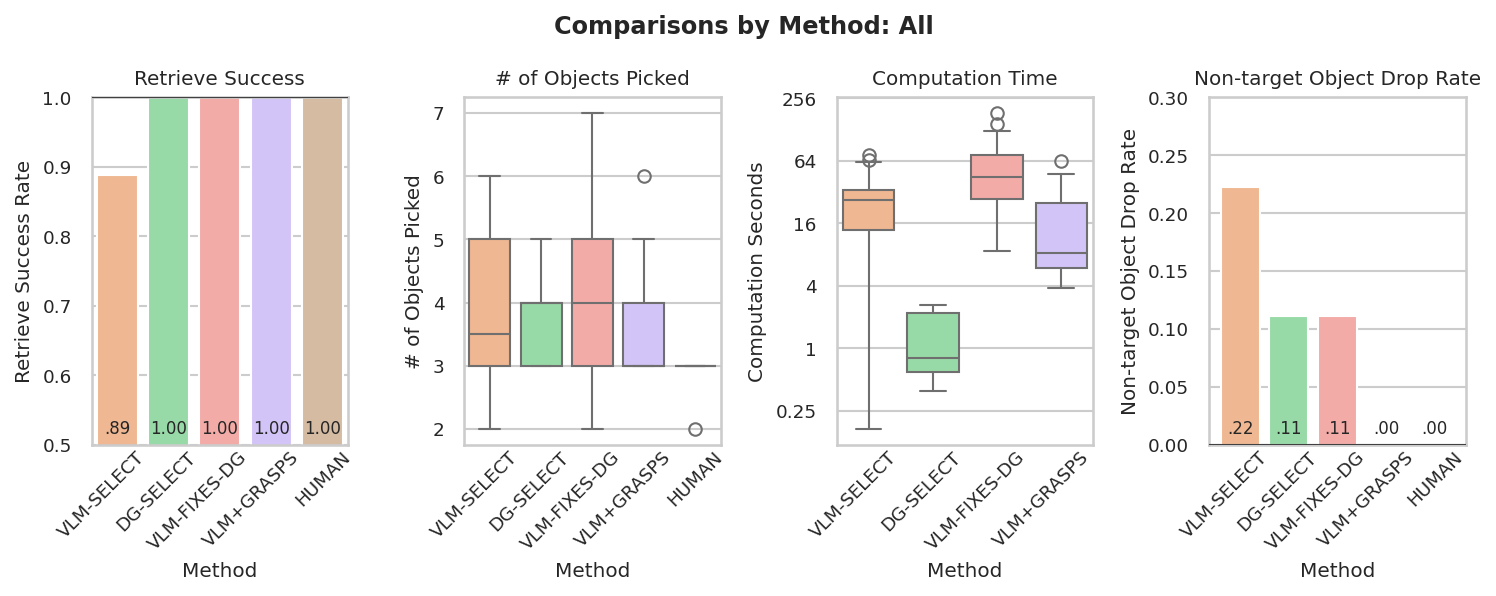

In [147]:
from matplotlib.transforms import BboxBase


def plot_method_comparisons_df(df: pd.DataFrame, subtitle: str = "", success_stacked: bool = False, accidental_drop_percent: bool = False):
    """Plots an experiment DataFrame's data by method, including:
        - Method Computation Time
        - Success Pick Count by Method
        - Retrieve Success by Method
        - Accidental Drops by Method

    Args:
        df (pd.DataFrame): Experiment DataFrame to plot.
        subtitle (str, optional): Subtitle of the plot. Defaults to "".
        success_stacked (bool, optional): Whether to plot success graph as a stacked bar 
            chart that splits a method success into dropped object and no dropped object successes.
            Defaults to False.
        accidental_drop_percent (bool, optional): Whether to plot accidental drop percentage by method.
            Defaults to False.
    """
    if len(df) == 0:
        return

    USE_XLABELS = True
    IS_REAL = "real" in EXPERIMENT_SUMMARY_CSV_PATH

    def desired_order(series: pd.Series, order: List[str], exclude: List[str] = []) -> List[str]:
        current_values = set(series.unique())
        ordered_and_present = [item for item in order if item in current_values]
        remaining_values = list(current_values - set(order) - set(exclude))
        remaining_values.sort()
        final_order = ordered_and_present + remaining_values
        return final_order

    def only_desired(series: pd.Series, order: List[str]) -> List[str]:
        current_values = set(series.unique())
        ordered_and_present = [item for item in order if item in current_values]
        return ordered_and_present

    METHOD_ORDER = desired_order(df["Method"], ["random","vlm_only", "dg_only", "vlm_dg", "dg_into_vlm", "human"])
    METHOD_ORDER_NO_HUMAN = desired_order(df["Method"], ["random","vlm_only", "dg_only", "vlm_dg", "dg_into_vlm"], exclude=["human"])
    XLABELS = ["RANDOM", "VLM-SELECT", "DG-SELECT", "VLM-FIXES-DG", "VLM+GRASPS", "HUMAN"]
    COLOR_MAP = {
        "random": PALETTE_COLORS[0],
        "vlm_only": PALETTE_COLORS[1],
        "dg_only": PALETTE_COLORS[2],
        "vlm_dg": PALETTE_COLORS[3],
        "dg_into_vlm": PALETTE_COLORS[4],
        "human": PALETTE_COLORS[5]
    }
    HUMAN_MODE = "line" # Options: "line", "line_only", "bar"

    if IS_REAL:
        XLABELS.remove("RANDOM")
    
    # Create a figure with a 2x2 grid of subplots
    fig, axs = plt.subplots(1, 4, figsize=(10, 4))
    fig.suptitle(f"{PLOT_PREFIX}Comparisons by Method: {subtitle}", fontweight='bold')
    
    def bar_labels(ax: axes.Axes, containers: List[container.Container], align: str = "bottom", hide_zeroes: bool = False, **kwargs):
        y_min, y_max = ax.get_ylim()
        pad = 0.02 * (y_max - y_min)

        for c in containers:
            for p in c:
                p = cast(patches.Rectangle, p)
                label = f"{p.get_height():.2f}".lstrip("0")

                if hide_zeroes and float(label) == 0:
                    continue

                bar_bottom = p.get_y()
                bar_top = p.get_y() + p.get_height()

                # Skip bars completely outside visible y-range
                if bar_top < y_min or bar_bottom > y_max:
                    continue

                if align == "bottom":
                    target_y = max(bar_bottom, y_min) + pad
                    va = "bottom"
                elif align == "top":
                    target_y = min(bar_top, y_max) - pad
                    va = "top"
                elif align == "top_above":
                    target_y = min(bar_top + pad, y_max - pad * 0.5)
                    va = "bottom"
                else:
                    target_y = max(bar_bottom, y_min) + pad
                    va = "bottom"

                target_x = p.get_x() + p.get_width() / 2.0
                ax.text(target_x, target_y, label, ha="center", va=va, clip_on=True, **kwargs)

        return ax

    def slant_x_axis(ax: axes.Axes):
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        # ax.tick_params(axis='x', which='major', pad=15)
        offset = mtrans.ScaledTranslation(15/72, 8/72, ax.figure.dpi_scale_trans)
        # Apply the offset to each label
        for label in ax.xaxis.get_majorticklabels():
            label.set_transform(label.get_transform() + offset)

    def plot_hline(ax: plt.Axes, y_value: float, label: str, show_label: bool = True):
        ax.axhline(y_value, color="black" if show_label else "#414141", linestyle="-", linewidth=1, zorder=100)
        va = "bottom"
        dy_points = 4
        if y_value > 0.95:
            va = "top"
            dy_points = -4
        elif y_value < 0.05:
            va = "bottom"
            dy_points = 16
        y_value_label = f"{y_value:.2f}".lstrip("0")
        if show_label:
            ax.annotate(
                f" {label} {y_value_label}",
                xy=(1, y_value),
                xycoords=ax.get_yaxis_transform(),
                xytext=(-6, dy_points),
                textcoords="offset points",
                ha="right",
                va=va,
                fontsize=8,
                color="black",
            )
    
    grasp_choice_df = get_grasp_choice_df(df)
    is_not_human = ~grasp_choice_df['Method'].eq("human")
    df_no_human = grasp_choice_df[is_not_human]
    ax = sns.boxplot(df_no_human, x="Method", y="Grasp Choice Duration", ax=axs[2], showfliers=True, hue="Method", palette=COLOR_MAP, order=METHOD_ORDER_NO_HUMAN, hue_order=METHOD_ORDER_NO_HUMAN)
    ax.set_title("Computation Time")
    ax.set_ylabel("Computation Seconds")
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.10g}'))
    if USE_XLABELS:
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(XLABELS[:-1])
    slant_x_axis(ax)

    filtered_df = df.loc[df["Experiment Result"] == "retrieved", ["Method", "Grasp Retracted Objects Count"]]
    ax = sns.boxplot(filtered_df, x="Method", y="Grasp Retracted Objects Count", ax=axs[1], hue="Method", palette=COLOR_MAP, order=METHOD_ORDER, hue_order=METHOD_ORDER)
    ax.set_title("# of Objects Picked")
    ax.set_ylabel("# of Objects Picked")
    if USE_XLABELS:
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(XLABELS)
    slant_x_axis(ax)
    
    def plot_success_stacked(df: pd.DataFrame, ax: plt.Axes):
        df = df[["Method", "Retrieve Success", "Accidental Dropped Objects Count", "Experiment Path", "Accidental Dropped Objects"]].copy()
        df["Accidental Dropped"] = df["Accidental Dropped Objects Count"] > 0
        group_success_percent = df.groupby(["Method", "Accidental Dropped"])["Retrieve Success"].mean()
        group_success_counts = df.groupby(["Method", "Accidental Dropped"])["Retrieve Success"].count()
        method_success_counts = df.groupby("Method")["Retrieve Success"].count()
        # % of successes that each group makes up out of the total successes
        group_success_proportions = group_success_counts / method_success_counts
        # % of total successes that each Accidental Dropped group contributes to
        group_absolute_success_percent = group_success_percent * group_success_proportions
        stacked_data = group_absolute_success_percent.unstack(fill_value=0)
        stacked_data.index = pd.Categorical(
            stacked_data.index,
            categories=METHOD_ORDER,
            ordered=True
        )
        stacked_data = stacked_data.sort_index()
        
        categories = stacked_data.columns
        bottom_data = stacked_data[categories[0]] # The first stack's height is its value
        
        # Plot the first stack (bottom)
        sns.barplot(
            x=stacked_data.index,
            y=stacked_data[categories[0]],
            dodge=False,
            hue=stacked_data.index,
            palette=COLOR_MAP,
            label=categories[0],
            ax=ax
        )

        # Plot the second stack (top), using the first stack's height as the 'bottom'
        sns.barplot(
            x=stacked_data.index,
            y=stacked_data[categories[1]],
            dodge=False,
            bottom=bottom_data,
            color='#CCCCCC',
            label=categories[1],
            ax=ax
        )

        ax.legend_.remove()

        # Add labels and legend
        ax.set_title("Retrieve Success by Method")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Success Rate")
        ax.set_xlabel("Method")
        # ax.legend(
        #     title="Dropped Objects",  # You can specify the legend title here
        #     loc='lower right',          # Position the legend relative to the anchor point
        # )            

        bar_labels(ax, ax.containers[:-1], align="bottom", fontsize=8, fontweight="medium")
        bar_labels(ax, ax.containers[-1:], align="bottom", hide_zeroes=True, fontsize=8, fontweight="medium")
        if USE_XLABELS:
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(XLABELS)
        slant_x_axis(ax)

        # Log partial successes
        def log_partial_successes(df: pd.DataFrame):
            partial_successes: pd.DataFrame = df.loc[df["Retrieve Success"] & df["Accidental Dropped"], ["Experiment Path", "Accidental Dropped Objects"]]

            runs_path = Path(RUNS_PATH).resolve()
            root_path = Path(ROOT_PATH).resolve()
            def get_local_path(exp_dir: str) -> str:
                local_dir = next(runs_path.glob(f"**/*{exp_dir}*"), None)
                if local_dir is not None:
                    return local_dir.relative_to(root_path)
                return ""

            partial_successes["Local Experiment Path"] = partial_successes["Experiment Path"].apply(get_local_path)
            partial_successes.to_csv(f"{PLOTS_PATH}/partial_successes_{to_snake_case(subtitle)}.csv", index=False, header=True)

        log_partial_successes(df) 
    
    def plot_success(df: pd.DataFrame, ax: plt.Axes):
        plot_df = df
        if HUMAN_MODE == "line_only":
            plot_df = df.loc[df["Method"] != "human"]
        plot_method_order = METHOD_ORDER_NO_HUMAN if HUMAN_MODE == "line_only" else METHOD_ORDER
        plot_xlabels = XLABELS[:-1] if HUMAN_MODE == "line_only" else XLABELS
        ax = sns.barplot(plot_df, x="Method", y="Retrieve Success", ax=ax, hue="Method", palette=COLOR_MAP, estimator="mean", order=plot_method_order, hue_order=plot_method_order, errorbar=None)
        ax.set_title("Retrieve Success")
        ax.set_ylim(0.5, 1)
        ax.set_ylabel("Retrieve Success Rate")
        
        # Plot human line
        human_df = df.loc[df["Method"] == "human", "Retrieve Success"]
        if len(human_df) > 0 and HUMAN_MODE in ["line", "line_only"]:
            human_success = float(human_df.mean())
            plot_hline(ax, human_success, "HUMAN", show_label=HUMAN_MODE == "line_only")
        
        bar_labels(ax, ax.containers, align="bottom", fontsize=8, fontweight="medium")
        if USE_XLABELS:
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(plot_xlabels)
        slant_x_axis(ax)

    if success_stacked:
        plot_success_stacked(df, axs[0])
    else:
        plot_success(df, axs[0])
    
    def plot_accidental_drop_count(df: pd.DataFrame, ax: plt.Axes):
        ax = sns.boxplot(df, x="Method", y="Accidental Dropped Objects Count", ax=ax, hue="Method", palette=COLOR_MAP, order=METHOD_ORDER, hue_order=METHOD_ORDER)
        ax.set_title("Accidental Drops")
        if USE_XLABELS:
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(XLABELS)
        slant_x_axis(ax)

    def plot_accidental_drop_percent(df: pd.DataFrame, ax: plt.Axes):
        # Plot percentage of successes that have accidental drops
        df = df[["Method", "Accidental Dropped Objects Count", "Retrieve Success"]].copy()
        df["Accidental Dropped"] = df["Accidental Dropped Objects Count"] > 0
        method_dropped_exp_counts = (df.groupby(["Method", "Accidental Dropped"])["Accidental Dropped"]
            .count()
            .unstack(fill_value=0)                  # columns become False/True
            .reindex(columns=[True], fill_value=0)
            [True]
        )
        method_exp_counts = df["Method"].value_counts()
        method_drop_rate = method_dropped_exp_counts / method_exp_counts
        method_drop_rate_df = method_drop_rate.to_frame(name="Accidental Drop Rate")
        
        plot_df = method_drop_rate_df
        if HUMAN_MODE == "line_only":
            plot_df = method_drop_rate_df.loc[method_drop_rate_df.index != "human"]
        plot_method_order = METHOD_ORDER_NO_HUMAN if HUMAN_MODE == "line_only" else METHOD_ORDER
        plot_xlabels = XLABELS[:-1] if HUMAN_MODE == "line_only" else XLABELS
        
        ax = sns.barplot(plot_df, x="Method", y="Accidental Drop Rate", ax=ax, hue="Method", palette=COLOR_MAP, estimator="mean", order=plot_method_order, hue_order=plot_method_order, errorbar=None)

        # Plot human accidental drop rate benchmark line
        if "human" in method_drop_rate.index and HUMAN_MODE in ["line", "line_only"]:
            human_drop_rate = float(method_drop_rate.loc["human"])
            plot_hline(ax, human_drop_rate, "HUMAN", show_label=HUMAN_MODE == "line_only")
        
        ax.set_ylim(0, 0.3)
        ax.set_title("Non-target Object Drop Rate")
        ax.set_ylabel("Non-target Object Drop Rate")
        bar_labels(ax, ax.containers, align="bottom", fontsize=8, fontweight="medium")
        if USE_XLABELS:
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(plot_xlabels)
        slant_x_axis(ax)

    if accidental_drop_percent:
        plot_accidental_drop_percent(df, axs[3])
    else:
        plot_accidental_drop_count(df, axs[3])
    
    plt.tight_layout()
    plt.plot()
    plt.savefig(f"./plots/comparisons_by_method_{to_snake_case(subtitle)}.png")

    # 3. Loop through each axis and save it individually
    ax: plt.Axes
    for i, ax in enumerate(axs):
        # Get the bounding box of the individual plot
        extent: BboxBase = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
        extent = extent.expanded(1.03, 1.01)

        # Save just that extent
        fig.savefig(f'./plots/comparisons_by_method_{to_snake_case(subtitle)}_{i}.png', bbox_inches=extent)

def plot_all_method_comparisons_df(ex_df: pd.DataFrame, prefix: str = "", **kwargs):
    """Plots method comparisons of an experiment DataFrame across:
        - All scenes
        - Structured scenes
        - Unstructured scenes

    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to plot.
        prefix (str, optional): Prefix to append to the titles. Defaults to "".
    """
    plot_method_comparisons_df(ex_df, f"{prefix}All", **kwargs)
    plot_method_comparisons_df(ex_df[ex_df["Scene Type"] == "structured"], f"{prefix}Structured", **kwargs)
    plot_method_comparisons_df(ex_df[ex_df["Scene Type"] == "unstructured"], f"{prefix}Unstructured", **kwargs)

plot_all_method_comparisons_df(ex_df, success_stacked=False, accidental_drop_percent=True)

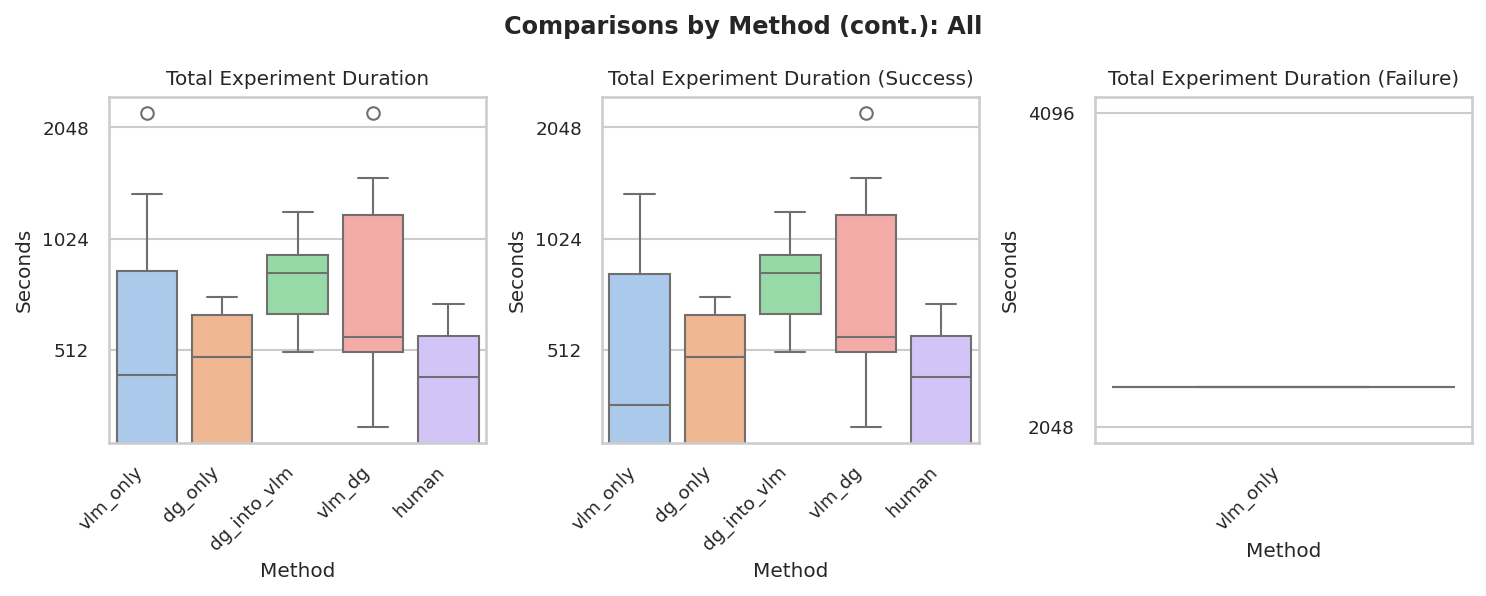

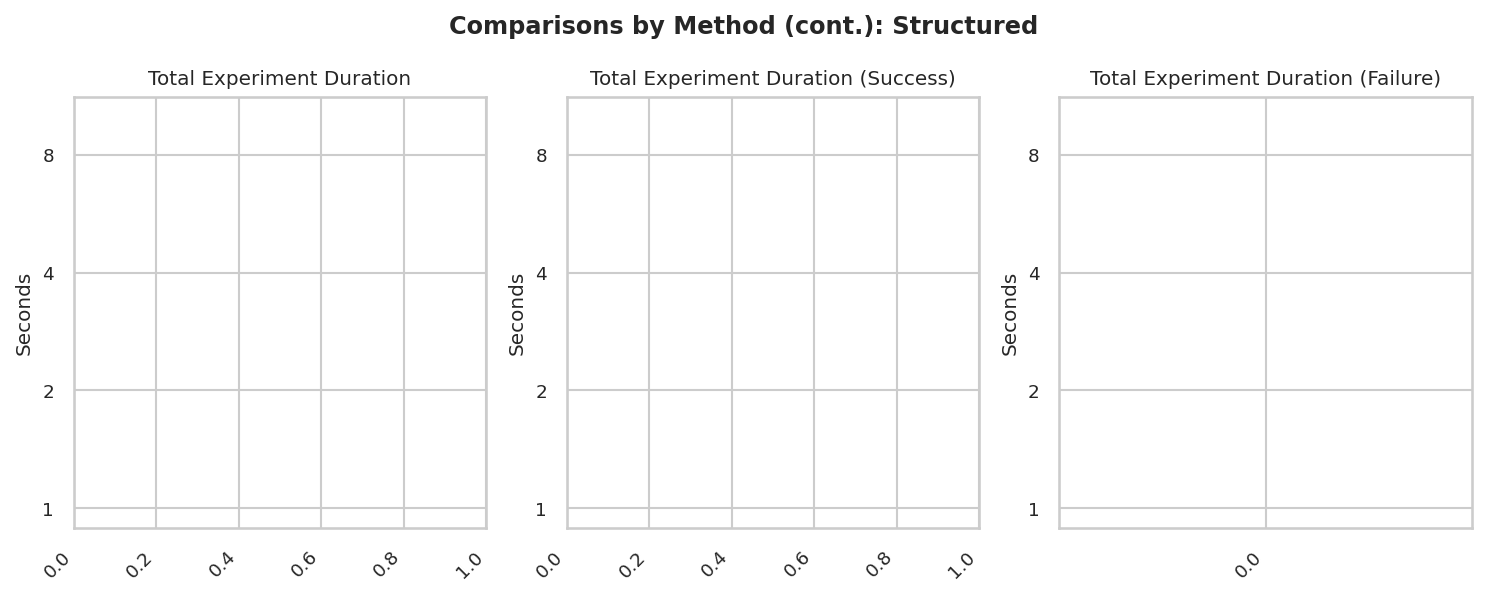

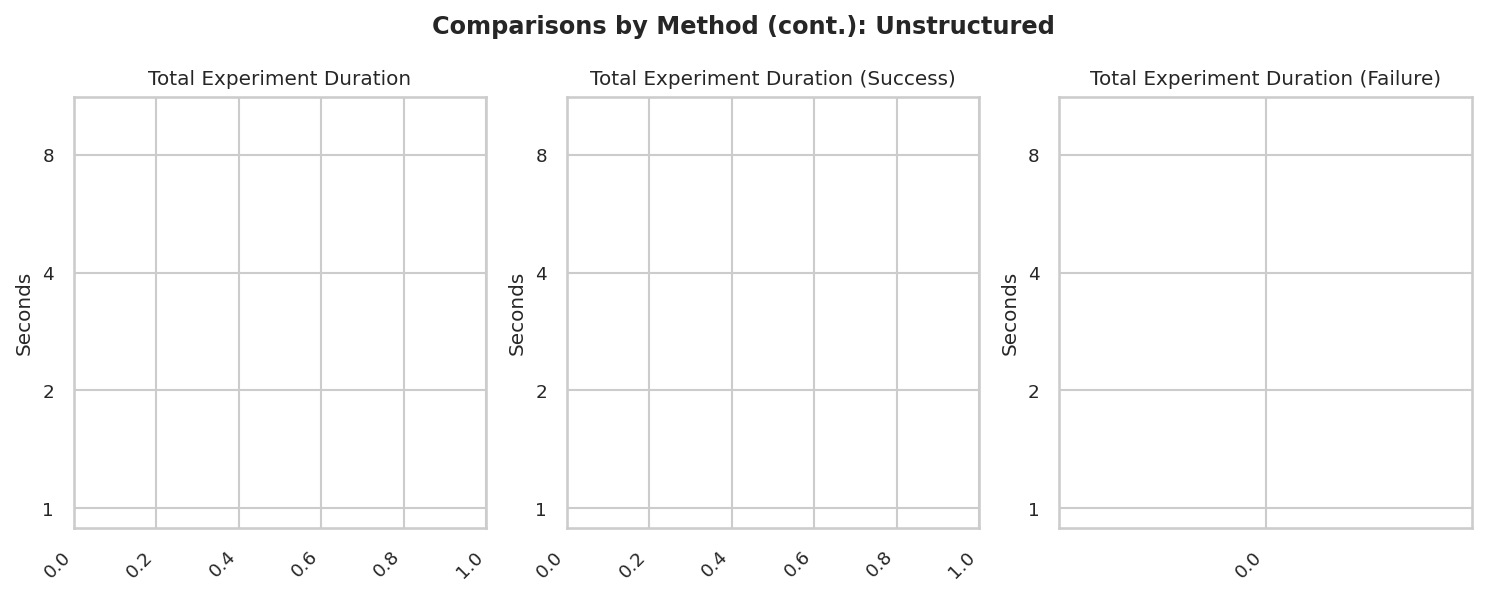

In [148]:
def plot_method_comparisons_cont_df(df: pd.DataFrame, subtitle: str = ""):
    """Plots an experiment DataFrame's data by method, including:
        - Total Experiment Duration
        - Total Experiment Duration (Success)
        - Total Experiment Duration (Failure)

    Args:
        df (pd.DataFrame): Experiment DataFrame to plot.
        subtitle (str, optional): Subtitle of the plot. Defaults to "".
    """
    if "Total Experiment Time" not in df.columns:
        warn("Experiment DataFrame missing 'Total Experiment Time'. The experiment_summary CSV may be outdated, so please rerun ./summarize_data.sh.")
        return
    
    def desired_order(series: pd.Series, order: List[str]) -> List[str]:
        current_values = set(series.unique())
        ordered_and_present = [item for item in order if item in current_values]
        remaining_values = list(current_values - set(order))
        remaining_values.sort()
        final_order = ordered_and_present + remaining_values
        return final_order

    METHOD_ORDER = desired_order(df["Method"], ["vlm_only", "dg_only", "dg_into_vlm", "vlm_dg", "human"])
    
    # Create a figure with a 2x2 grid of subplots
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f"Comparisons by Method (cont.): {subtitle}", fontweight='bold')
    
    def bar_labels(ax: axes.Axes):
        # Iterate through all containers
        for container in ax.containers:
            # Get the heights of the bars
            labels = [f'{p.get_height():.2f}' for p in container]
            # Use a loop to place labels at a fixed y-position (e.g., y=0)
            for i, p in enumerate(container):
                ax.text(p.get_x() + p.get_width() / 2., 0.05, labels[i],
                        ha='center', va='bottom')
        return ax

    def slant_x_axis(ax: axes.Axes):
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    ax = sns.boxplot(df, x="Method", y="Total Experiment Time", ax=axs[0], showfliers=True, hue="Method", order=METHOD_ORDER, hue_order=METHOD_ORDER)
    ax.set_title("Total Experiment Duration")
    ax.set_ylabel("Seconds")
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.10g}'))
    slant_x_axis(ax)

    success_df = df[df["Experiment Result"] == "retrieved"]
    ax = sns.boxplot(success_df, x="Method", y="Total Experiment Time", ax=axs[1], showfliers=True, hue="Method", order=METHOD_ORDER, hue_order=METHOD_ORDER)
    ax.set_title("Total Experiment Duration (Success)")
    ax.set_ylabel("Seconds")
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.10g}'))
    slant_x_axis(ax)

    fail_df = df[df["Experiment Result"] != "retrieved"]
    ax = sns.boxplot(fail_df, x="Method", y="Total Experiment Time", ax=axs[2], showfliers=True, hue="Method", order=METHOD_ORDER, hue_order=METHOD_ORDER)
    ax.set_title("Total Experiment Duration (Failure)")
    ax.set_ylabel("Seconds")
    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.10g}'))
    slant_x_axis(ax)
    
    plt.tight_layout()
    plt.plot()
    plt.savefig(f"./plots/comparisons_by_method_cont_{to_snake_case(subtitle)}.png")

def plot_all_method_comparisons_cont_df(ex_df: pd.DataFrame, prefix: str = ""):
    """Plots additional method comparisons of an experiment DataFrame across:
        - All scenes
        - Structured scenes
        - Unstructured scenes

    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to plot.
        prefix (str, optional): Prefix to append to the titles. Defaults to "".
    """
    plot_method_comparisons_cont_df(ex_df, f"{prefix}All")
    plot_method_comparisons_cont_df(ex_df[ex_df["Scene Type"] == "structured"], f"{prefix}Structured")
    plot_method_comparisons_cont_df(ex_df[ex_df["Scene Type"] == "unstructured"], f"{prefix}Unstructured")

plot_all_method_comparisons_cont_df(ex_df)

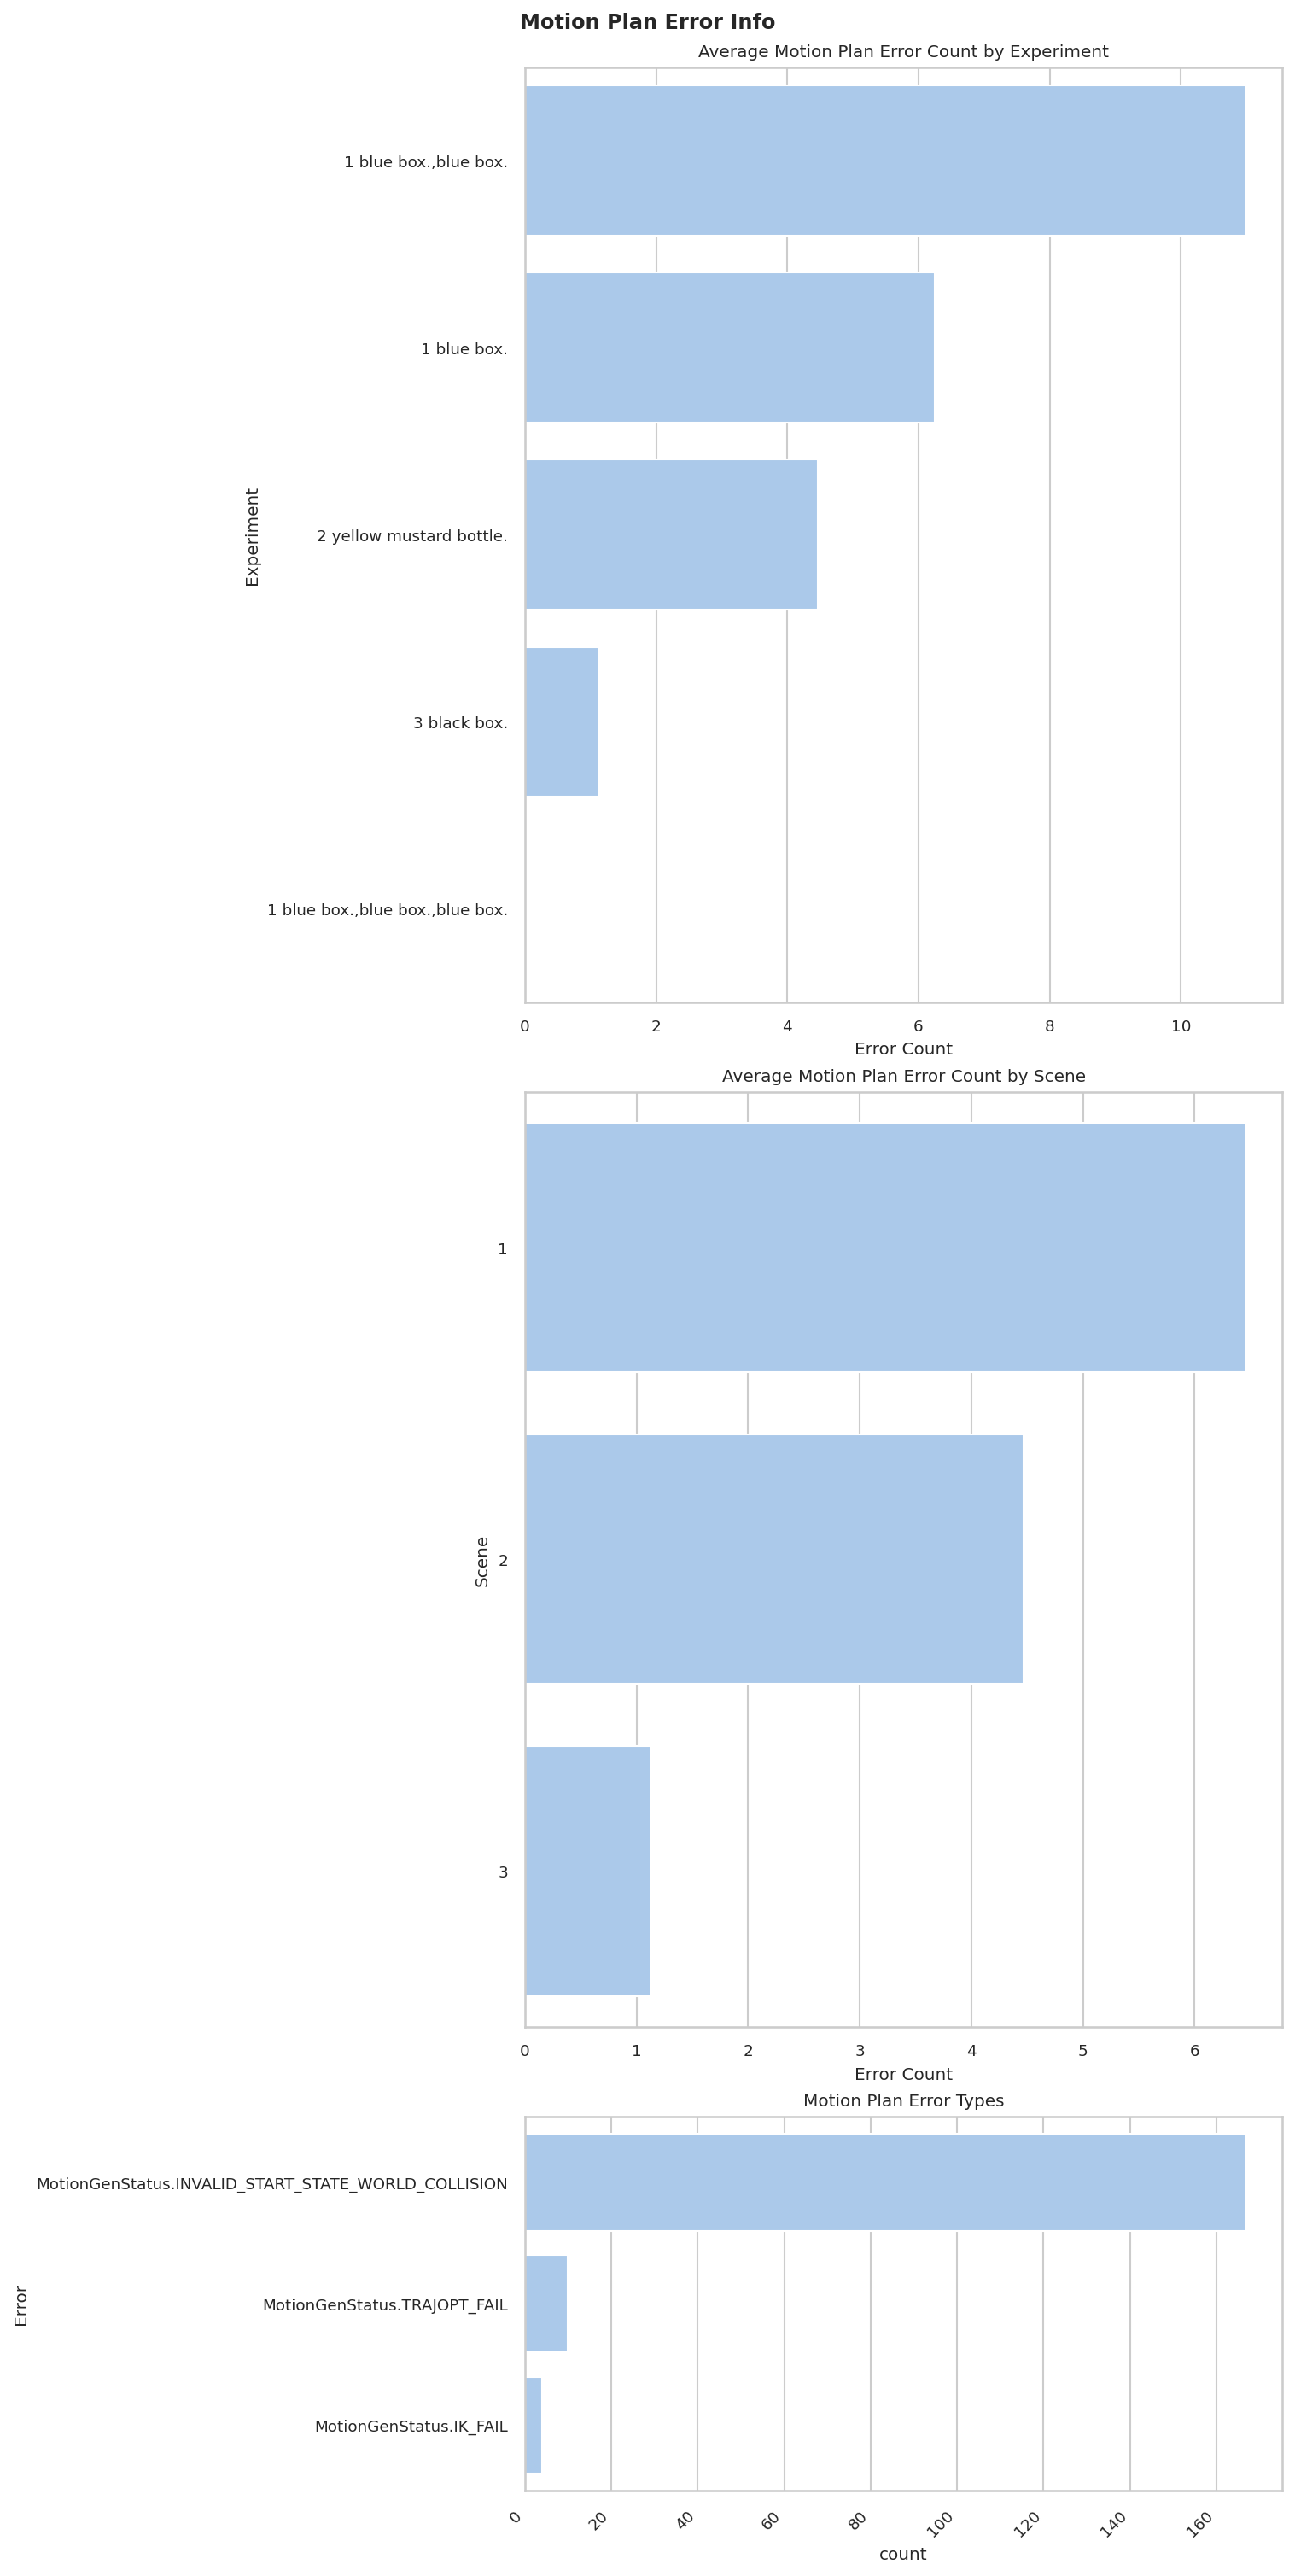

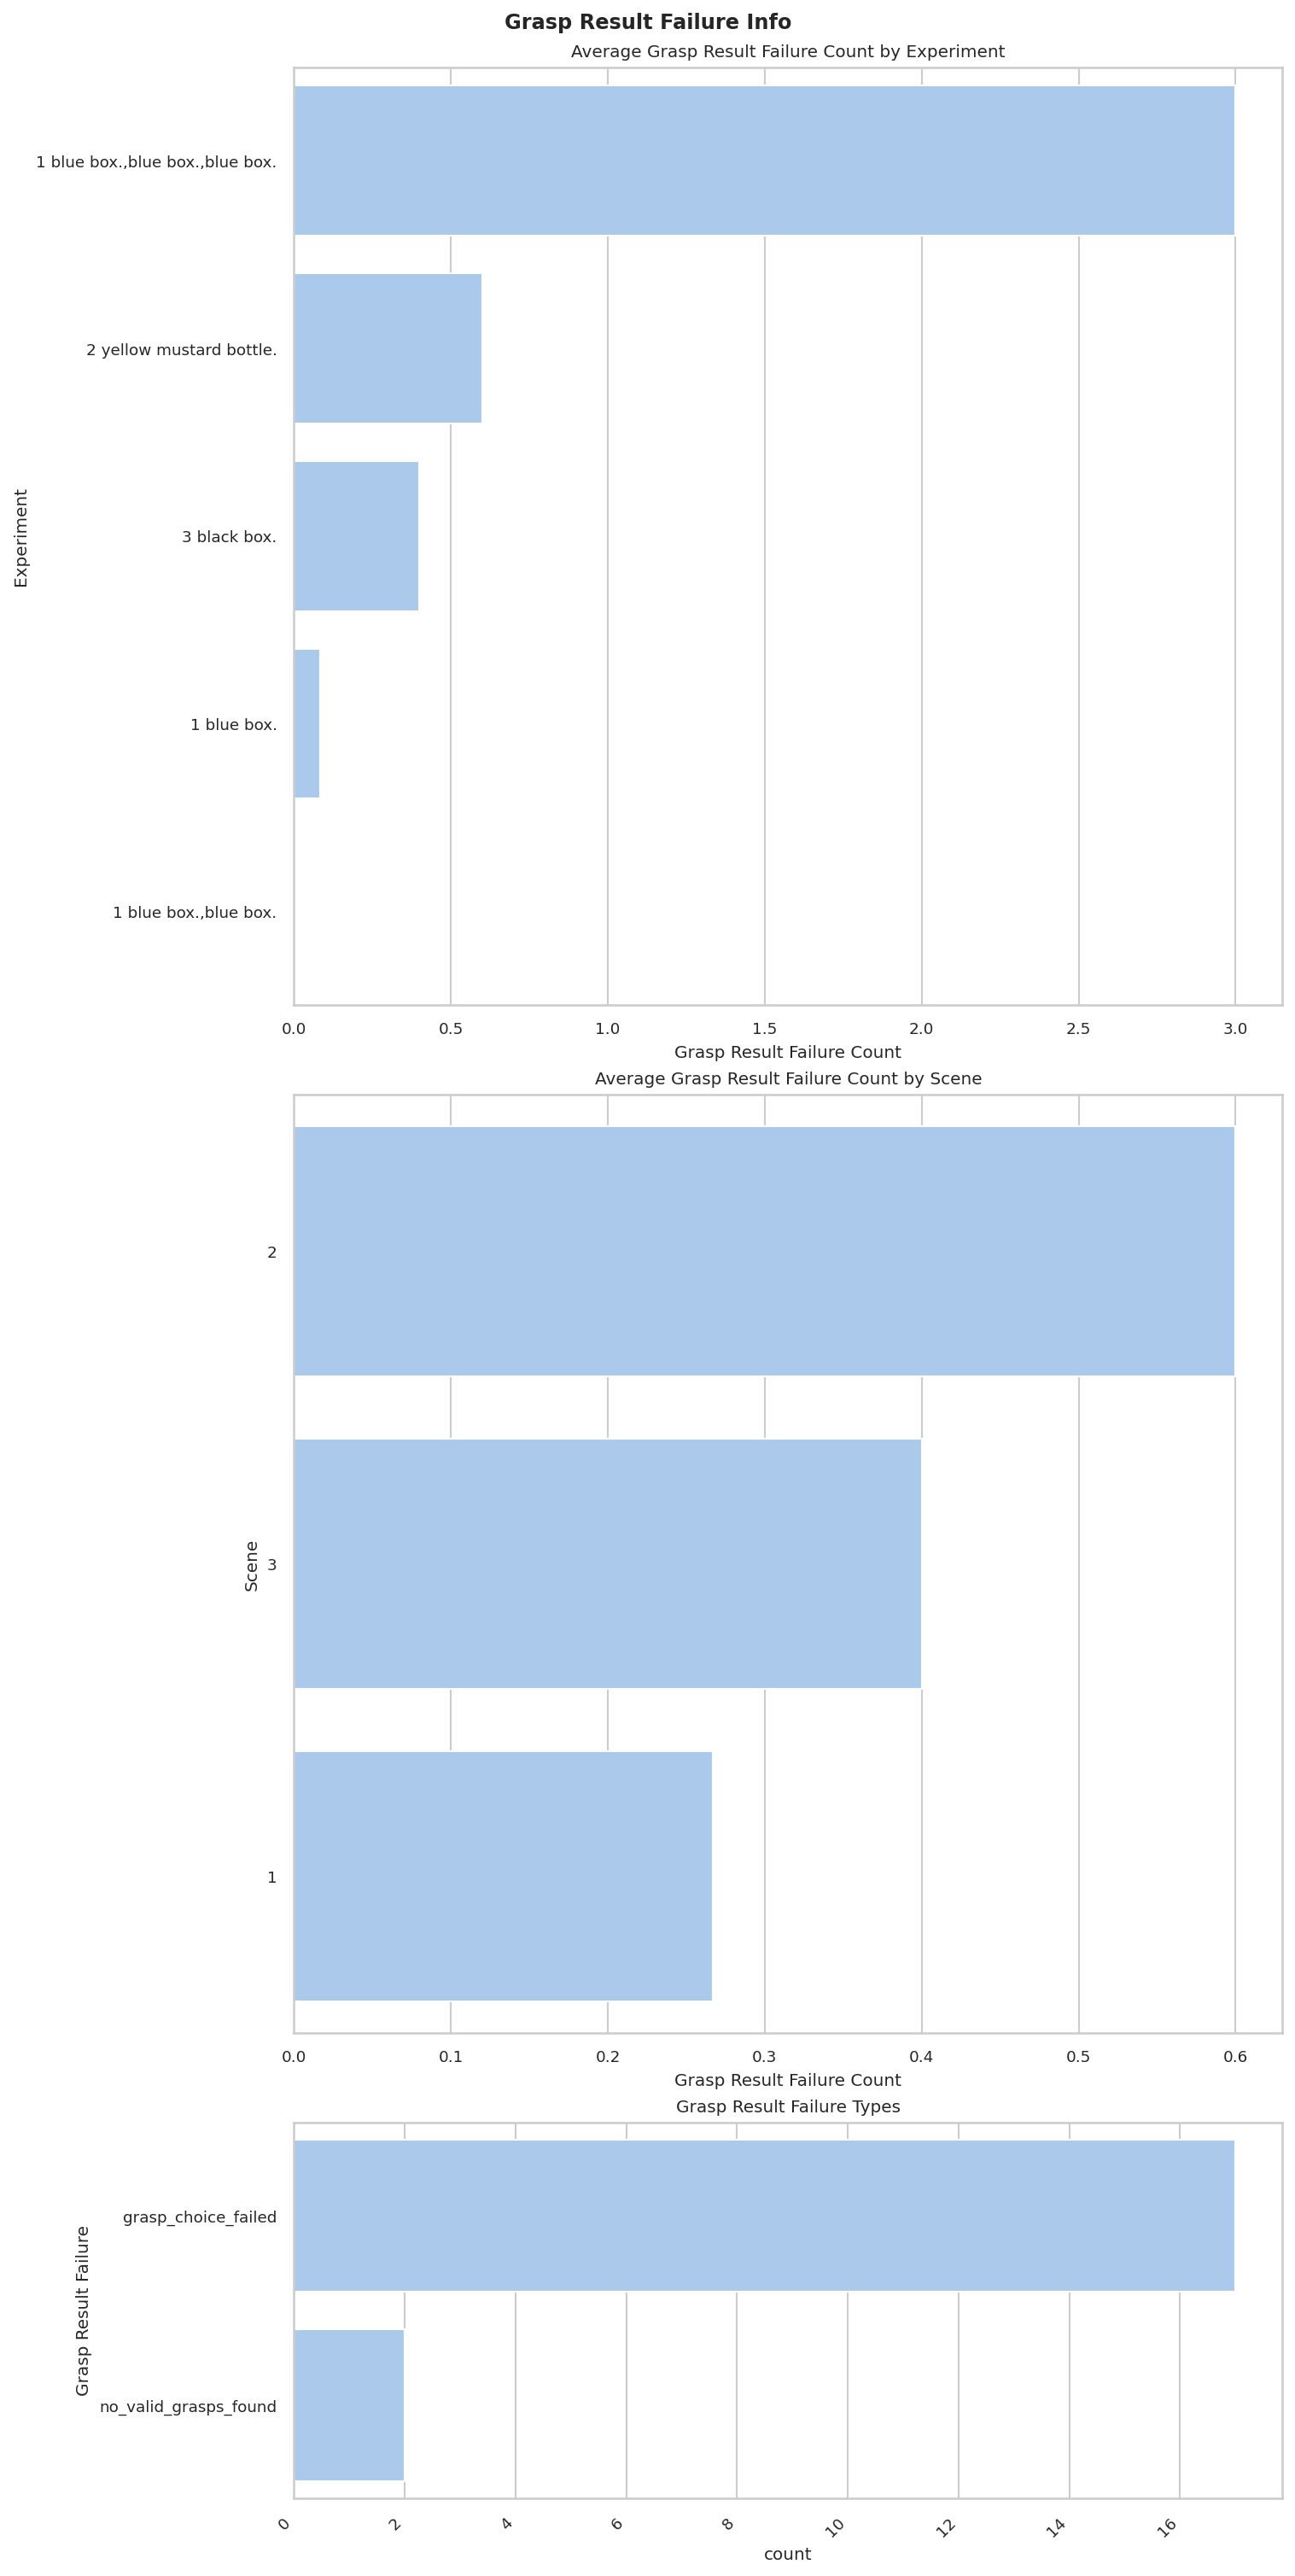

In [149]:
def plot_error_breakdown(df: pd.DataFrame, category: str, title: str = ""):
    """Plots the breakdown of errors in an experiment DataFrame, including:
        - Error Count by Experiment
        - Error Count by Scene
        - Error Types

    Args:
        df (pd.DataFrame): Experiment DataFrame to plot. 
        category (str): Category to use as an error. The category should have the column "{category} Count".
        title (str, optional): Title of the plot. Defaults to "". If "", then it uses the category as the title.
    """
    def slant_x_axis(ax):
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    if title == "":
        title = category
    category_count = f"{category} Count"
    
    fig = plt.figure(figsize=(10, 20), constrained_layout=True)
    fig.suptitle(f"{title} Info", fontweight='bold')
    ax0 = fig.add_subplot(12, 1, (1, 5)) 
    ax1 = fig.add_subplot(12, 1, (6, 10))
    ax2 = fig.add_subplot(12, 1, (11, 12))
    
    experiment_df = df.groupby('Experiment')[category_count].mean().reset_index().sort_values(by=category_count, ascending=False)
    ax = sns.barplot(experiment_df, x=category_count, y="Experiment", ax=ax0, errorbar=None)
    ax.set_title(f"Average {title} Count by Experiment")
    
    scene_df = df.groupby('Scene')[category_count].mean().reset_index().sort_values(by=category_count, ascending=False)
    ax = sns.barplot(scene_df, x=category_count, y="Scene", ax=ax1, errorbar=None)
    ax.set_title(f"Average {title} Count by Scene")
    
    error_series = df[category].str.split(",").explode().reset_index(drop=True)
    ax = sns.countplot(y=error_series, ax=ax2, order=error_series.value_counts().index)
    ax.set_title(f"{title} Types")
    
    slant_x_axis(ax)
    plt.plot()
    plt.savefig(f"{PLOTS_PATH}/error_info_{to_snake_case(title)}.png")

plot_error_breakdown(ex_df, category="Error", title="Motion Plan Error")
plot_error_breakdown(ex_df, category="Grasp Result Failure")

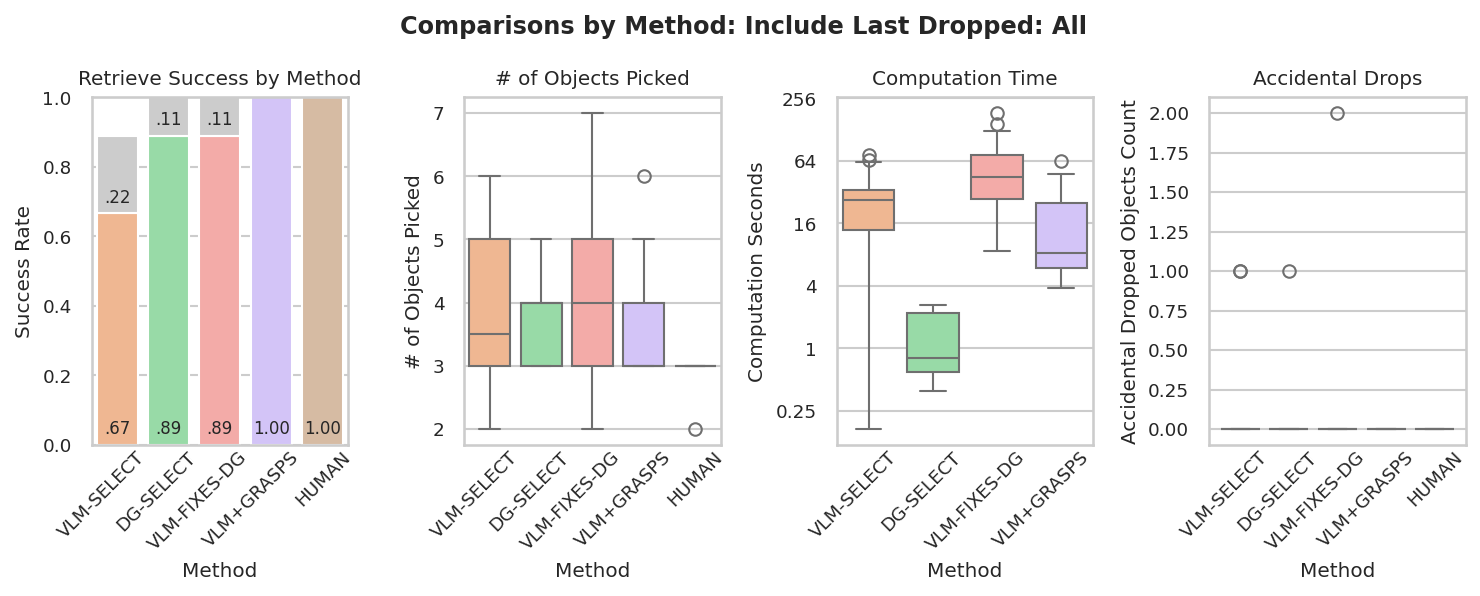

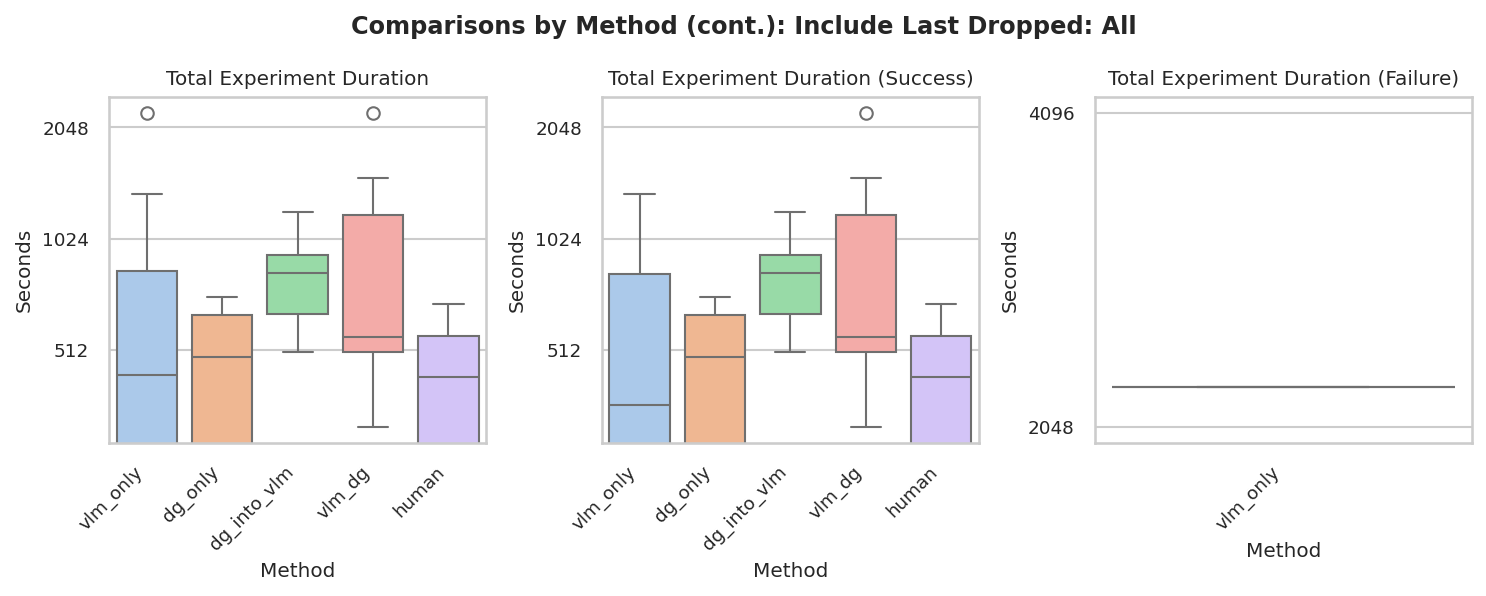

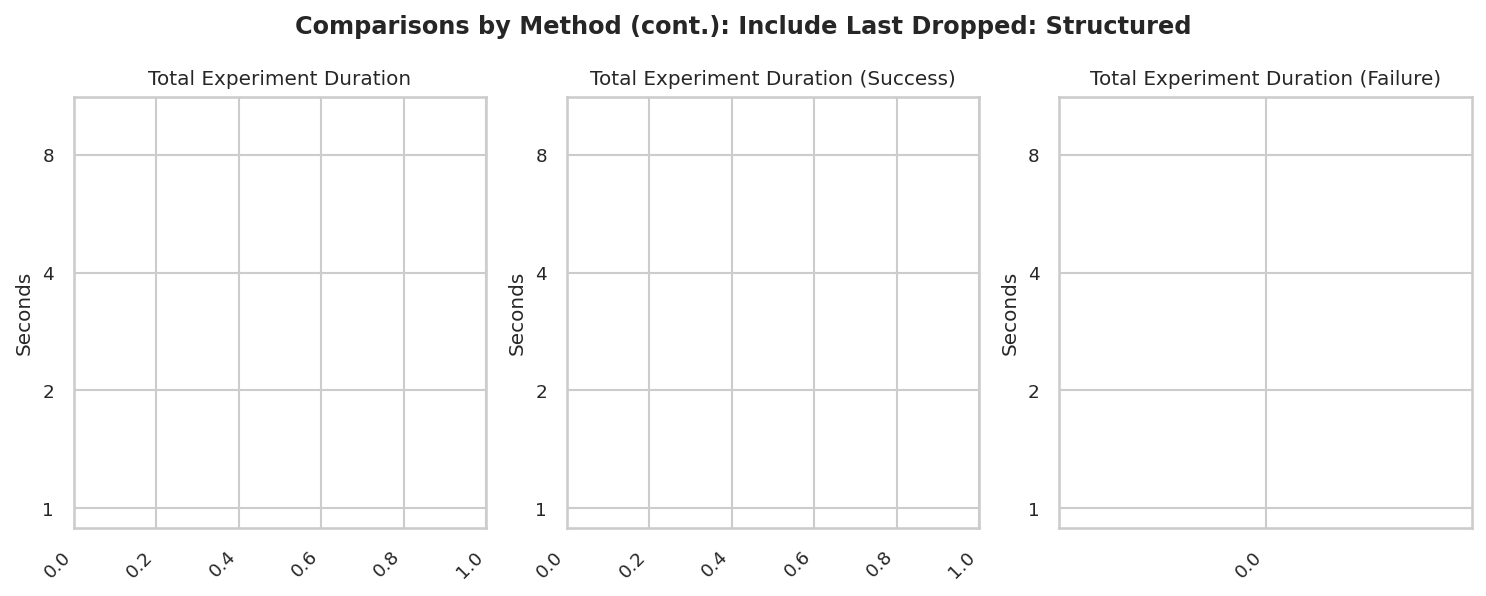

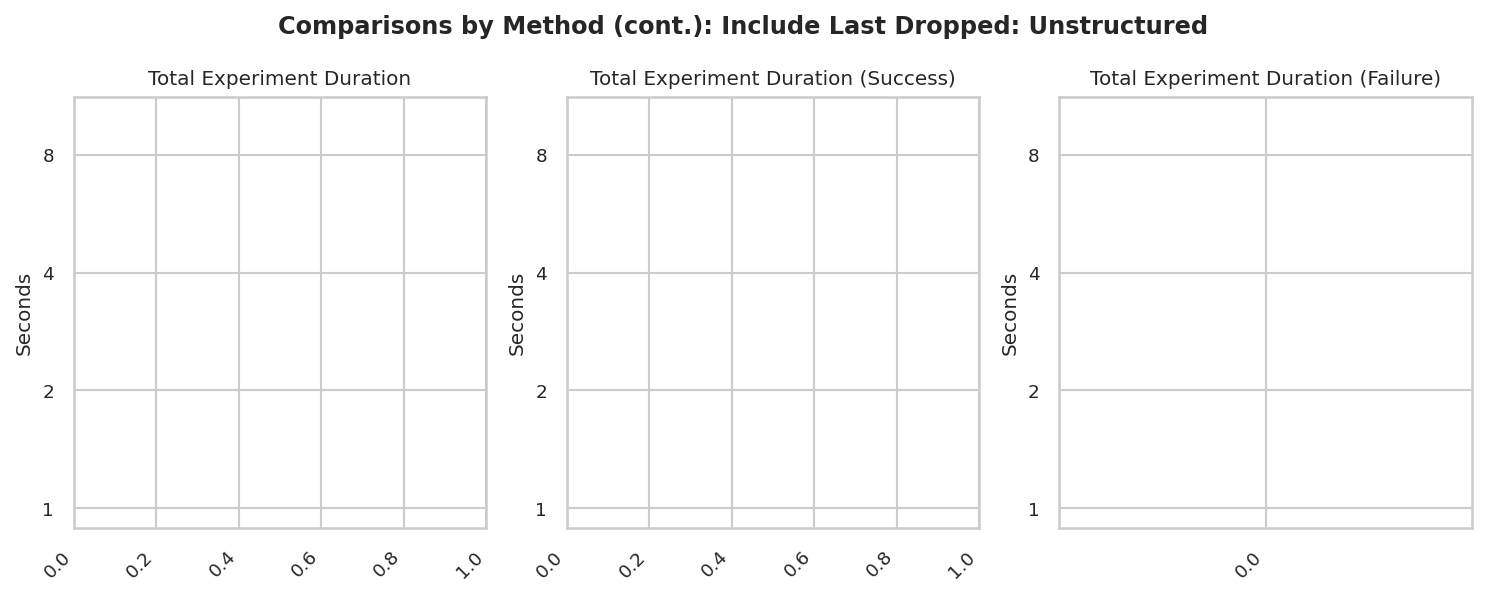

In [150]:
def include_last_dropped__plot_all_comparisons_df(ex_df: pd.DataFrame):
    """Plots all method comparisons for an experiment DataFrame, 
    except we consider experiements that picked up the target object 
    but dropped it while retreiving it as a success.

    Args:localhost
        ex_df (pd.DataFrame): Experiment DataFrame to plot.
    """
    def process_row(row):
        if type(row["Grasped"]) is not str:
            return False
        last_grasped = row["Grasped"].split("],[")[-1].strip("['']").split("', '")
        if len(row["Grasped"].split("],[")) > 1:
            second_to_last_grasped = row["Grasped"].split("],[")[-2].strip("['']").split("', '")
            return row["Experiment Result"] == "dropped" and (row["Target Object"] in last_grasped or row["Target Object"] in second_to_last_grasped)
        else:
            return row["Experiment Result"] == "dropped" and row["Target Object"] in last_grasped

    pd.set_option('display.max_colwidth', None)
    new_df = ex_df.copy()
    new_df['Grasped Target Last'] = new_df.apply(process_row, axis=1)

    # If we successfully grasped the target object in our last grasp, 
    # then consider it a sucess (even if we fail the retreival)
    new_df.loc[new_df['Grasped Target Last'] == True,"Retrieve Success"] = True
    
    plot_all_method_comparisons_df(new_df, prefix="Include Last Dropped: ", success_stacked=True)
    plot_all_method_comparisons_cont_df(new_df, prefix="Include Last Dropped: ")

include_last_dropped__plot_all_comparisons_df(ex_df)

,Experiment Path
0,trial_2025-12-06_14-29-26__scene2__dg_only/2__yellow_mustard_bottle___dg_only
16,trial_manual__real_trials__vlm_only/real_vlm_only_new_scene1_exp3
37,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_3__black_box___vlm_dg
42,trial_2025-12-08_15-18-36__scene3__vlm_only/3__exp_2__black_box___vlm_only


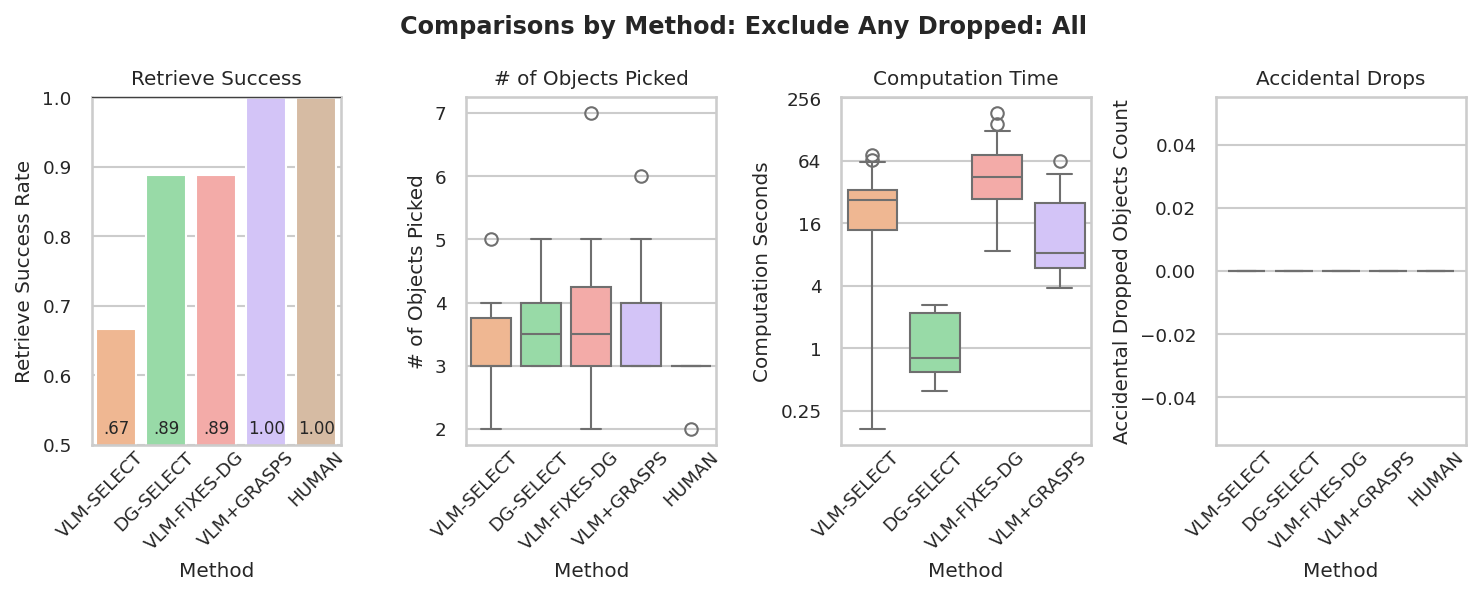

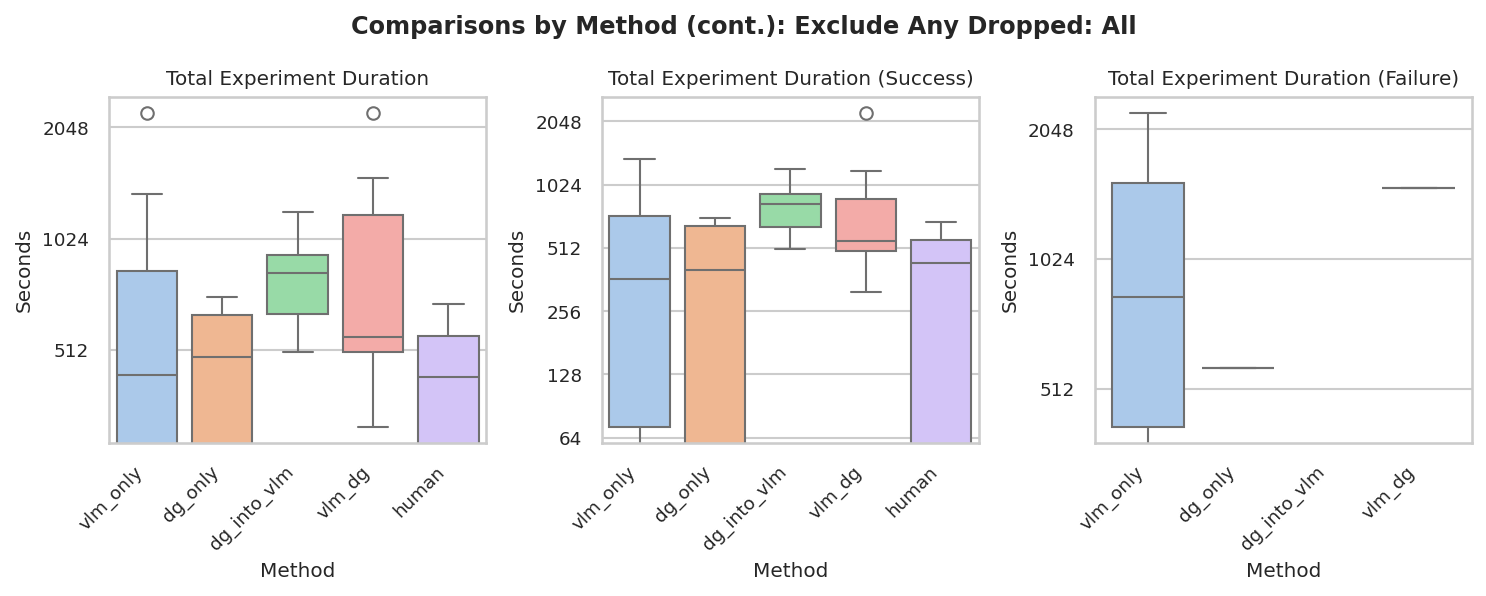

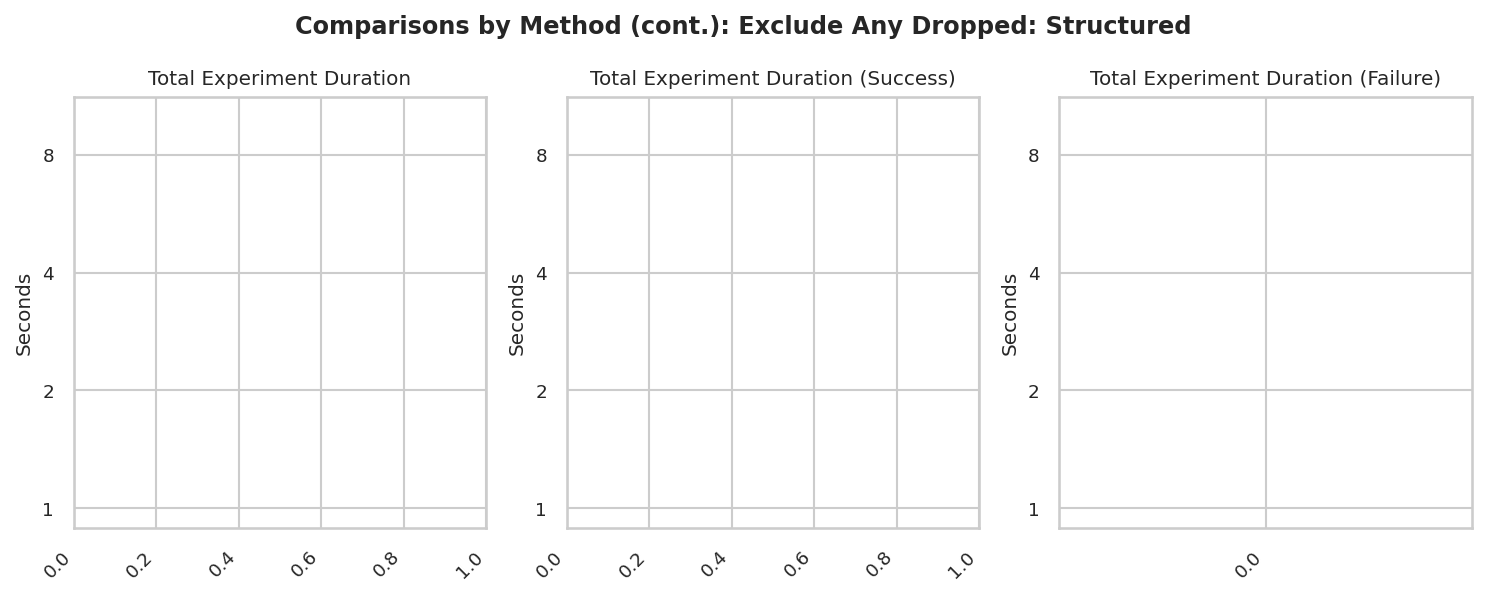

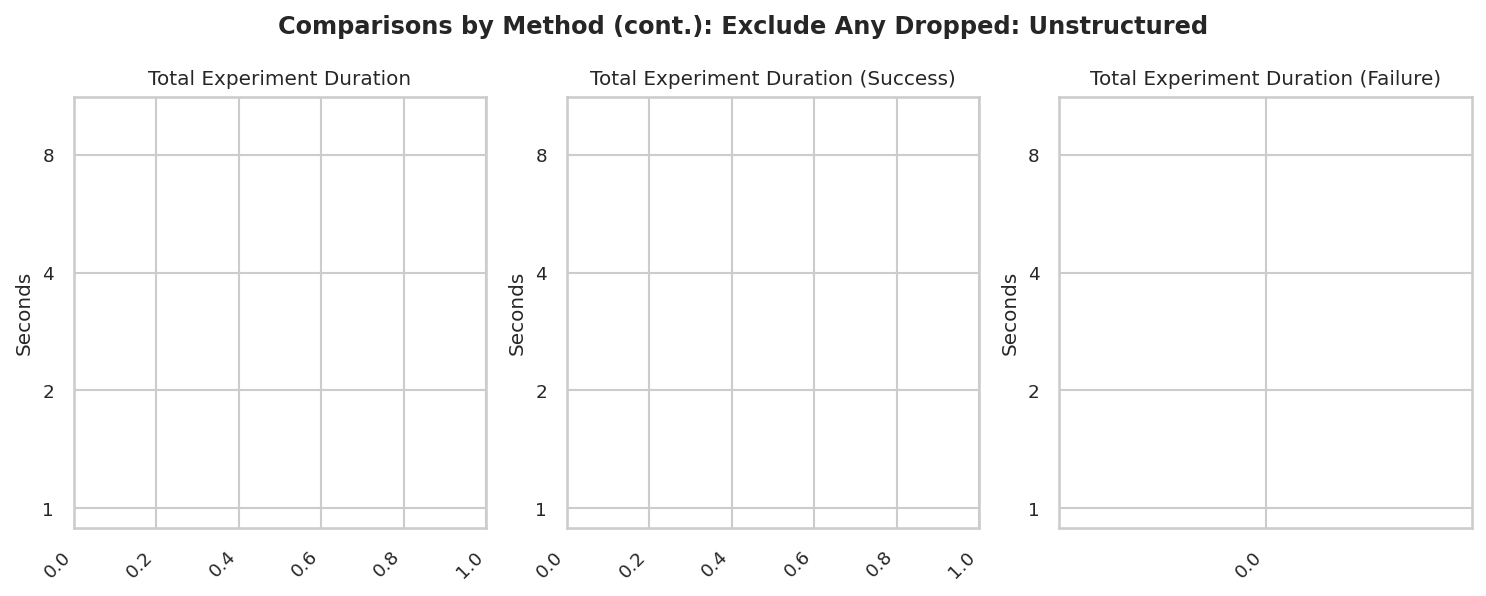

In [151]:
def exclude_any_dropped__plot_all_comparisons_df(ex_df: pd.DataFrame):
    """Plots all method comparisons for an experiment DataFrame, 
    except we consider any experiements that dropped any objects to be
    a failure.

    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to plot.
    """
    new_df = ex_df.copy()
    new_df2 = ex_df.copy()
    
    new_df.loc[new_df["Accidental Dropped Objects Count"] != 0, ["Retrieve Success", "Experiment Result", "Accidental Dropped Objects Count"]] = [False, "dropped", 0]
    
    plot_all_method_comparisons_df(new_df, prefix="Exclude Any Dropped: ")
    plot_all_method_comparisons_cont_df(new_df, prefix="Exclude Any Dropped: ")
    return new_df2.loc[new_df2["Accidental Dropped Objects Count"] != 0]

df_dropped = exclude_any_dropped__plot_all_comparisons_df(ex_df)
# display(df_dropped.columns)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
display(df_dropped[["Experiment Path"]])

In [152]:
grasp_choice_df = get_grasp_choice_df(ex_df)
longest_grasps = grasp_choice_df.nlargest(20, 'Grasp Choice Duration')
display(longest_grasps)

,Method,Experiment Path,Grasp Choice Duration
38,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_2__black_box___vlm_dg,184.260675
36,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__black_box___vlm_dg,146.156744
36,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__black_box___vlm_dg,124.344199
37,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_3__black_box___vlm_dg,119.190939
37,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_3__black_box___vlm_dg,115.387932
38,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_2__black_box___vlm_dg,104.512147
38,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_2__black_box___vlm_dg,88.211109
37,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_3__black_box___vlm_dg,86.488472
38,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_2__black_box___vlm_dg,82.118657
38,vlm_dg,trial_2025-12-08_18-00-46__scene3__vlm_dg/3__exp_2__black_box___vlm_dg,75.344267


In [153]:
# ^^^^^^^^^^ ADD NEW CODE BLOCKS ABOVE ^^^^^^^^^^ #

# Check to see if there are any errors.
check_results()

Data Analysis Results:
